## SpaceShip Titanic 

Réalisé par : Imane BOUKHARI,
Lynda CHABOUNI,
Léo BEN HATAT,
Khady CAMARA DANSO

# 1. Etude préalable des données 
## 1.1. Analyse des fichiers 

Librairies et extensions 

In [1]:
import pandas as pd  
import numpy as np  
import seaborn as sns  
import matplotlib.pyplot as plt 
from matplotlib.ticker import FuncFormatter  
import matplotlib.patches as mpatches 

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, PredefinedSplit
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    recall_score, precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, classification_report
)
from sklearn.cluster import KMeans


RANDOM_STATE = 42
CV_FOLDS     = 5
N_CLUSTERS   = 5
N_ACM_COMPS  = 10
OUTPUT_CSV   = "spaceship_titanic_powerbi.csv"
import warnings

# Supprimer les messages d'erreurs
warnings.filterwarnings('ignore')

from scipy.stats import chi2_contingency
sns.set(style="whitegrid")


COLORS = {
    'cyan':   '#00d4ff', 'red':  '#ff6b6b', 'green': '#7fff7f',
    'amber':  '#ffcc44', 'purple':'#b77fff', 'muted': '#9e9e9e',
    'bg':     '#070b14', 'bg2':  '#0d1626', 'bg3':   '#152035',
    'text':   '#c8d8f0', 'border':'#1e3050'
}
CLUSTER_COLORS = [COLORS['cyan'], COLORS['red'], COLORS['green'],
                  COLORS['amber'], COLORS['purple']]

plt.rcParams.update({
    'figure.facecolor': COLORS['bg'],  'axes.facecolor':  COLORS['bg2'],
    'axes.edgecolor':   COLORS['border'], 'axes.labelcolor': COLORS['text'],
    'xtick.color':      COLORS['muted'], 'ytick.color':     COLORS['muted'],
    'text.color':       COLORS['text'],  'grid.color':      COLORS['border'],
    'grid.linestyle':   '--',            'grid.alpha':      0.4,
})



Importation des données

In [2]:
chemin = 'Données/train.csv'
train_data = pd.read_csv(chemin)

chemin = 'Données/test.csv'
test_data = pd.read_csv(chemin)

display(train_data.head())
print(f'The shape of the train dataset is {train_data.shape}')
print(f'The shape of the test dataset is {test_data.shape}\n')

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


The shape of the train dataset is (8693, 14)
The shape of the test dataset is (4277, 13)



Liste des variables présentes dans le dataset

| **Nom de la variable** | **Description** |
|:----------------------:|:---------------:|
| PassengerId | Un identifiant unique pour chaque passager. Chaque identifiant prend la forme de gggg_pp, où gggg indique le groupe avec lequel le passager voyage et pp est son numéro au sein du groupe. Les membres d'un groupe sont souvent des membres de la famille, mais pas toujours. |
| HomePlanet | La planète d'où le passager est parti, généralement sa planète de résidence permanente. |
| CryoSleep | Indique si le passager a choisi d'être mis en animation suspendue pendant la durée du voyage. Les passagers en cryosleep sont confinés dans leurs cabines. |
| Cabin | Le numéro de cabine où le passager séjourne. Il prend la forme de pont/numéro/côté, où le côté peut être soit P pour bâbord, soit S pour tribord. (deck/num/side) |
| Destination | Planète de destination |
| Age | Âge du passager |
| VIP | Indique si le passager a payé pour un service VIP spécial pendant le voyage. |
| RoomService | Dépenses en Room Service |
| FoodCourt | Dépenses au Food Court |
| ShoppingMall | Dépenses au Shopping Mall |
| Spa | Dépenses au Spa |
| VRDeck | Dépenses au VR Deck |
| Name | Prénom et nom du passager |
| Transported |  Indique si le passager a été transporté vers une autre dimension. Il s'agit de la cible, la colonne que vous essayez de prédire. |

# 1.2 Valeurs manquantes et aberrantes

In [3]:
# Statistiques descriptives globales
stats = train_data.describe(include='all').T
stats['% de valeurs manquantes'] = 100 * train_data.isnull().sum() / len(train_data)
display(stats)

# Tableau synthétique des valeurs manquantes
manquantes = pd.DataFrame({
    'Nom': train_data.columns,
    'Total de valeurs': len(train_data),
    'Total de valeurs manquantes': train_data.isnull().sum().values,
    'Pourcentage de valeurs manquantes': 100 * train_data.isnull().sum().values / len(train_data)
})
manquantes = manquantes[manquantes['Total de valeurs manquantes'] > 0]
manquantes = manquantes[['Nom', 'Total de valeurs', 'Total de valeurs manquantes', 'Pourcentage de valeurs manquantes']]
manquantes.sort_values('Total de valeurs manquantes', ascending=False, inplace=True)
display(manquantes.style.format({'Pourcentage de valeurs manquantes': '{:.2f}%'}).set_caption('Valeurs manquantes par variable'))

,count,unique,top,freq,mean,std,min,25%,50%,75%,max,% de valeurs manquantes
PassengerId,8693,8693,0001_01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
HomePlanet,8492,3,Earth,4602,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.312205
CryoSleep,8476,2,False,5439,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.496261
Cabin,8494,6560,G/734/S,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.289198
Destination,8511,3,TRAPPIST-1e,5915,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.093639
Age,8514.0,NaN,NaN,NaN,28.82793,14.489021,0.0,19.0,27.0,38.0,79.0,2.059128
VIP,8490,2,False,8291,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.335212
RoomService,8512.0,NaN,NaN,NaN,224.687617,666.717663,0.0,0.0,0.0,47.0,14327.0,2.082135
FoodCourt,8510.0,NaN,NaN,NaN,458.077203,1611.48924,0.0,0.0,0.0,76.0,29813.0,2.105142
ShoppingMall,8485.0,NaN,NaN,NaN,173.729169,604.696458,0.0,0.0,0.0,27.0,23492.0,2.392730


,Nom,Total de valeurs,Total de valeurs manquantes,Pourcentage de valeurs manquantes
2,CryoSleep,8693,217,2.50%
9,ShoppingMall,8693,208,2.39%
6,VIP,8693,203,2.34%
1,HomePlanet,8693,201,2.31%
12,Name,8693,200,2.30%
3,Cabin,8693,199,2.29%
11,VRDeck,8693,188,2.16%
8,FoodCourt,8693,183,2.11%
10,Spa,8693,183,2.11%
4,Destination,8693,182,2.09%


Vérification des doublons

In [4]:
duplicates = train_data.duplicated()
print("\nNumber of duplicates :", duplicates.sum())

if duplicates.any():
    print("\nLines with duplicates :")
    print(train_data[duplicates])


Number of duplicates : 0


Nous visualisons la distribution des variables numériques et détectons les valeurs aberrantes à l'aide de la méthode de l'IQR. Les outliers sont remplacés par la médiane pour préserver la distribution.

In [5]:
num_cols = train_data.select_dtypes(include=np.number).columns
for col in num_cols:
    Q1 = train_data[col].quantile(0.25)
    Q3 = train_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((train_data[col] < lower) | (train_data[col] > upper)).sum()
    print(f"{col} : {outliers} valeurs aberrantes détectées")
    mediane = train_data[col].median()
    train_data.loc[train_data[col] < lower, col] = mediane
    train_data.loc[train_data[col] > upper, col] = mediane

Age : 77 valeurs aberrantes détectées
RoomService : 1861 valeurs aberrantes détectées
FoodCourt : 1823 valeurs aberrantes détectées
ShoppingMall : 1829 valeurs aberrantes détectées
Spa : 1788 valeurs aberrantes détectées
VRDeck : 1809 valeurs aberrantes détectées


In [6]:
num_cols = train_data.select_dtypes(include=np.number).columns
outlier_cols = {}

outlier_mask = pd.Series(False, index=train_data.index)

for col in num_cols:
    Q1 = train_data[col].quantile(0.25)
    Q3 = train_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask = (train_data[col] < lower) | (train_data[col] > upper)
    outlier_cols[col] = mask
    outlier_mask = outlier_mask | mask

df_outliers = train_data[outlier_mask].copy()
df_outliers['OutlierColumns'] = df_outliers.index.to_series().apply(lambda i: [col for col, m in outlier_cols.items() if m.loc[i]])

df_outliers

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,OutlierColumns
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,0.0,44.0,Juanna Vines,True,"[RoomService, FoodCourt, ShoppingMall, VRDeck]"
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,0.0,0.0,0.0,49.0,Altark Susent,False,"[RoomService, VRDeck]"
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,0.0,70.0,0.0,0.0,2.0,Willy Santantines,True,"[FoodCourt, VRDeck]"
6,0006_01,Earth,False,F/2/S,TRAPPIST-1e,26.0,False,42.0,0.0,3.0,0.0,0.0,Billex Jacostaffey,True,"[RoomService, ShoppingMall]"
8,0007_01,Earth,False,F/3/S,TRAPPIST-1e,35.0,False,0.0,0.0,17.0,0.0,0.0,Andona Beston,True,[ShoppingMall]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8686,9275_02,Europa,False,A/97/P,TRAPPIST-1e,32.0,False,1.0,0.0,0.0,50.0,34.0,Diram Conable,False,"[RoomService, Spa, VRDeck]"
8687,9275_03,Europa,NaN,A/97/P,TRAPPIST-1e,30.0,False,0.0,0.0,0.0,2.0,0.0,Atlasym Conable,True,[Spa]
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,0.0,0.0,0.0,74.0,Gravior Noxnuther,False,[VRDeck]
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,0.0,1.0,0.0,Fayey Connon,True,[Spa]


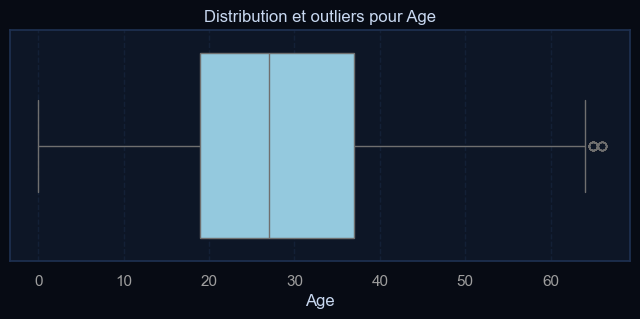

Age : 30 valeurs aberrantes détectées


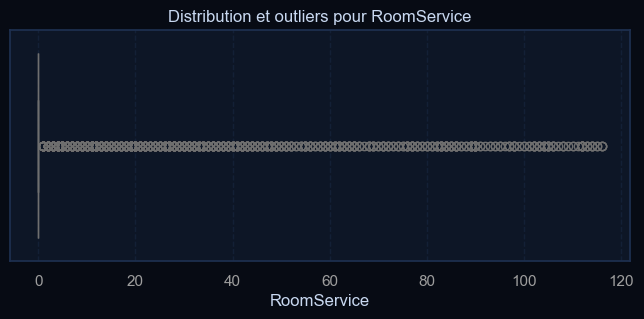

RoomService : 1074 valeurs aberrantes détectées


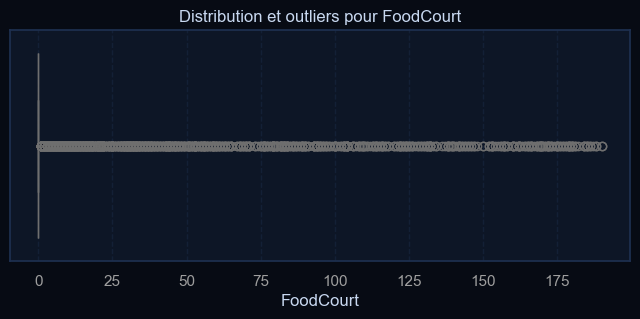

FoodCourt : 1231 valeurs aberrantes détectées


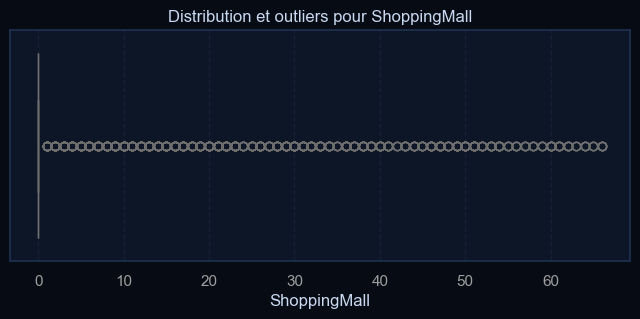

ShoppingMall : 1069 valeurs aberrantes détectées


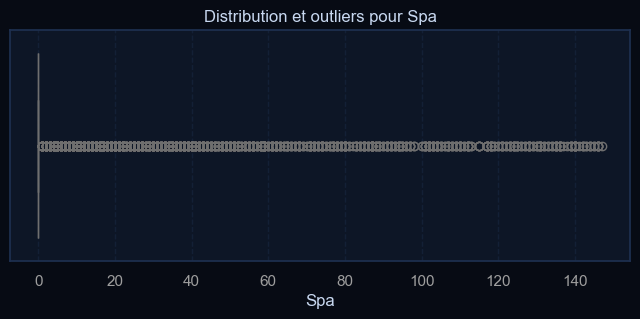

Spa : 1398 valeurs aberrantes détectées


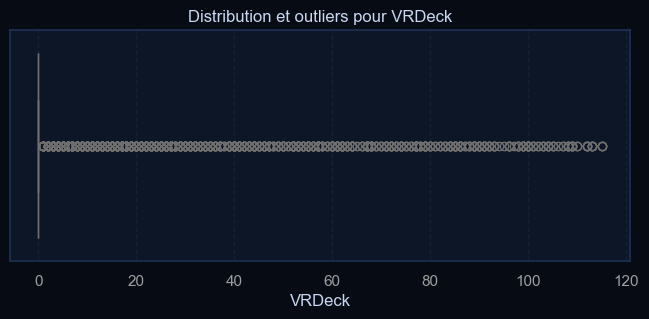

VRDeck : 1201 valeurs aberrantes détectées


In [7]:
num_cols = train_data.select_dtypes(include=np.number).columns
for col in num_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=train_data[col], color='skyblue')
    plt.title(f'Distribution et outliers pour {col}')
    plt.show()
    Q1 = train_data[col].quantile(0.25)
    Q3 = train_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((train_data[col] < lower) | (train_data[col] > upper)).sum()
    print(f"{col} : {outliers} valeurs aberrantes détectées")
    mediane = train_data[col].median()
    train_data.loc[train_data[col] < lower, col] = mediane
    train_data.loc[train_data[col] > upper, col] = mediane

## 1.3 Variables ajoutées

In [8]:
##-----------------  SUR LE TRAIN  -------------------------------

# A. Exploitation de PassengerId (Group & IsAlone)
train_data['Group'] = train_data['PassengerId'].str.split('_').str[0]
train_data['GroupSize'] = train_data.groupby('Group')['Group'].transform('count')
train_data['IsAlone'] = (train_data['GroupSize'] == 1).astype(int)

# B. Découpage de la cabine (Deck, Num, Side)
train_data[['Deck', 'CabinNum', 'Side']] = train_data['Cabin'].str.split('/', expand=True)

# C. Analyse des dépenses
exp_features = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
train_data['TotalSpent'] = train_data[exp_features].sum(axis=1)
train_data['HasSpent']   = (train_data['TotalSpent'] > 0).astype(int)

# D. Nom de famille et taille de la famille
train_data['FamilyName'] = train_data['Name'].str.split().str[-1]
train_data['FamilySize'] = train_data.groupby('FamilyName')['FamilyName'].transform('count')
    
# On considère ces passagers comme voyageant seuls (FamilySize=1, HasFamily=0)
train_data['FamilySize'] = train_data['FamilySize'].fillna(1).astype(int)
train_data['HasFamily']  = (train_data['FamilySize'] > 1).astype(int)


##-----------------  SUR LE TEST   -------------------------------

# A. Exploitation de PassengerId (Group & IsAlone)
test_data['Group'] = test_data['PassengerId'].str.split('_').str[0]
test_data['GroupSize'] = test_data.groupby('Group')['Group'].transform('count')
test_data['IsAlone'] = (test_data['GroupSize'] == 1).astype(int)

# B. Découpage de la cabine (Deck, Num, Side)
test_data[['Deck', 'CabinNum', 'Side']] = test_data['Cabin'].str.split('/', expand=True)

# C. Analyse des dépenses
exp_features = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
test_data['TotalSpent'] = test_data[exp_features].sum(axis=1)
test_data['HasSpent']   = (test_data['TotalSpent'] > 0).astype(int)

# D. Nom de famille et taille de la famille
test_data['FamilyName'] = test_data['Name'].str.split().str[-1]
test_data['FamilySize'] = test_data.groupby('FamilyName')['FamilyName'].transform('count')

# On considère ces passagers comme voyageant seuls (FamilySize=1, HasFamily=0)
test_data['FamilySize'] = test_data['FamilySize'].fillna(1).astype(int)
test_data['HasFamily']  = (test_data['FamilySize'] > 1).astype(int)

##-----------------  ENLEVER VARIABLE  CABINE   -------------------------------
train_data = train_data.drop('Cabin', axis=1)
test_data  = test_data.drop('Cabin', axis=1)


train_data.head()


,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,...,GroupSize,IsAlone,Deck,CabinNum,Side,TotalSpent,HasSpent,FamilyName,FamilySize,HasFamily
0,0001_01,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,...,1,1,B,0,P,0.0,0,Ofracculy,1,0
1,0002_01,Earth,False,TRAPPIST-1e,24.0,False,0.0,0.0,0.0,0.0,...,1,1,F,0,S,0.0,0,Vines,4,1
2,0003_01,Europa,False,TRAPPIST-1e,58.0,True,0.0,0.0,0.0,0.0,...,2,0,A,0,S,0.0,0,Susent,6,1
3,0003_02,Europa,False,TRAPPIST-1e,33.0,False,0.0,0.0,0.0,0.0,...,2,0,A,0,S,0.0,0,Susent,6,1
4,0004_01,Earth,False,TRAPPIST-1e,16.0,False,0.0,0.0,0.0,0.0,...,1,1,F,1,S,0.0,0,Santantines,6,1


## 1.4 Imputation des valeurs manquantes 

Les valeurs manquantes sont imputées : la médiane pour les variables numériques et la modalité la plus fréquente (mode) pour les variables catégorielles. Cette étape est essentielle pour garantir la qualité des analyses ultérieures.

In [9]:
data = pd.concat([train_data.drop('Transported', axis=1), test_data], ignore_index=True)

#TRAIN 
train_data['HomePlanet'] = train_data['HomePlanet'].fillna(data['HomePlanet'].mode()[0])  # mode
train_data['CryoSleep'] = train_data['CryoSleep'].fillna(data['CryoSleep'].mode()[0])  # mode
train_data['Destination'] = train_data['Destination'].fillna(data['Destination'].mode()[0])  # mode
train_data['Age'] = train_data['Age'].fillna(data['Age'].mean())  # moyenne
train_data['VIP'] = train_data['VIP'].fillna(data['VIP'].mode()[0])  # mode = False
train_data['RoomService'] = train_data['RoomService'].fillna(data['RoomService'].mean())  #  moyenne
train_data['FoodCourt'] = train_data['FoodCourt'].fillna(data['FoodCourt'].mean())  #  moyenne
train_data['ShoppingMall'] = train_data['ShoppingMall'].fillna(data['ShoppingMall'].mean())  #  moyenne
train_data['Spa'] = train_data['Spa'].fillna(data['Spa'].mean())  #  moyenne
train_data['VRDeck'] = train_data['VRDeck'].fillna(data['VRDeck'].mean())  #  moyenne
train_data['CabinNum'] = train_data['CabinNum'].fillna(data['CabinNum'].mode()[0])  #  mode
train_data['Deck'] = train_data['Deck'].fillna(data['Deck'].mode()[0])  # mode
train_data['Side'] = train_data['Side'].fillna(data['Side'].mode()[0])  #  mode

# TEST
test_data['HomePlanet'] = test_data['HomePlanet'].fillna(data['HomePlanet'].mode()[0])  # mode
test_data['CryoSleep'] = test_data['CryoSleep'].fillna(data['CryoSleep'].mode()[0])  # mode
test_data['Destination'] = test_data['Destination'].fillna(data['Destination'].mode()[0])  # mode
test_data['Age'] = test_data['Age'].fillna(data['Age'].mean())  # moyenne
test_data['VIP'] = test_data['VIP'].fillna(data['VIP'].mode()[0])  # mode = False
test_data['RoomService'] = test_data['RoomService'].fillna(data['RoomService'].mean())  # moyenne
test_data['FoodCourt'] = test_data['FoodCourt'].fillna(data['FoodCourt'].mean())  # moyenne
test_data['ShoppingMall'] = test_data['ShoppingMall'].fillna(data['ShoppingMall'].mean())  # moyenne
test_data['Spa'] = test_data['Spa'].fillna(data['Spa'].mean())  # moyenne
test_data['VRDeck'] = test_data['VRDeck'].fillna(data['VRDeck'].mean())  # moyenne
test_data['CabinNum'] = test_data['CabinNum'].fillna(data['CabinNum'].mode()[0])  # mode
test_data['Deck'] = test_data['Deck'].fillna(data['Deck'].mode()[0])  # mode
test_data['Side'] = test_data['Side'].fillna(data['Side'].mode()[0])  # mode


# Tableau synthétique des valeurs manquantes
manquantes = pd.DataFrame({
    'Nom': train_data.columns,
    'Total de valeurs': len(train_data),
    'Total de valeurs manquantes': train_data.isnull().sum().values,
    'Pourcentage de valeurs manquantes': 100 * train_data.isnull().sum().values / len(train_data)
})
manquantes = manquantes[manquantes['Total de valeurs manquantes'] > 0]
manquantes = manquantes[['Nom', 'Total de valeurs', 'Total de valeurs manquantes', 'Pourcentage de valeurs manquantes']]
manquantes.sort_values('Total de valeurs manquantes', ascending=False, inplace=True)
display(manquantes.style.format({'Pourcentage de valeurs manquantes': '{:.2f}%'}).set_caption('Valeurs manquantes par variable'))

,Nom,Total de valeurs,Total de valeurs manquantes,Pourcentage de valeurs manquantes
11,Name,8693,200,2.30%
21,FamilyName,8693,200,2.30%


In [10]:
# Imputation variables ajoutées ----- TRAIN

# Check des cabines manquantes dans les groupes 
indices_groups_missing_cabin = train_data[train_data['Deck'].isnull()]['PassengerId'].values  

# Les mêmes groupes auront potentiellement le meme numero cabine

global_mode = data[['Deck', 'CabinNum', 'Side']].mode().iloc[0]  # Global mode of cabin deck, num, and side

for index in indices_groups_missing_cabin:
    group = index.split('_')[0]  
    group_df = data[data['Group'] == group]  
    try:
        cabin_group_mode = group_df[~group_df['CabinNum'].isnull()][['Deck', 'CabinNum', 'Side']].mode().iloc[0]  
        train_data.loc[train_data['PassengerId'] == index, ['Deck', 'CabinNum', 'Side']] = cabin_group_mode.values 
    except IndexError:
        train_data.loc[train_data['PassengerId'] == index, ['Deck', 'CabinNum', 'Side']] = global_mode.values


# Imputation variables ajoutées ----- TEST

# Check des cabines manquantes dans les groupes 
indices_groups_missing_cabin = test_data[test_data['Deck'].isnull()]['PassengerId'].values  

# Les mêmes groupes auront potentiellement le meme numero cabine
global_mode = data[['Deck', 'CabinNum', 'Side']].mode().iloc[0]  

for index in indices_groups_missing_cabin:
    group = index.split('_')[0] 
    group_df = data[data['Group'] == group] 
    try:
        cabin_group_mode = group_df[~group_df['CabinNum'].isnull()][['Deck', 'CabinNum', 'Side']].mode().iloc[0]  
        test_data.loc[test_data['PassengerId'] == index, ['Deck', 'CabinNum', 'Side']] = cabin_group_mode.values 
    except IndexError:
        test_data.loc[test_data['PassengerId'] == index, ['Deck', 'CabinNum', 'Side']] = global_mode.values


In [11]:
# Verification
print('Train data\n\n', train_data.isnull().sum(), '\n')
print('Test data\n\n', test_data.isnull().sum())

Train data

 PassengerId       0
HomePlanet        0
CryoSleep         0
Destination       0
Age               0
VIP               0
RoomService       0
FoodCourt         0
ShoppingMall      0
Spa               0
VRDeck            0
Name            200
Transported       0
Group             0
GroupSize         0
IsAlone           0
Deck              0
CabinNum          0
Side              0
TotalSpent        0
HasSpent          0
FamilyName      200
FamilySize        0
HasFamily         0
dtype: int64 

Test data

 PassengerId      0
HomePlanet       0
CryoSleep        0
Destination      0
Age              0
VIP              0
RoomService      0
FoodCourt        0
ShoppingMall     0
Spa              0
VRDeck           0
Name            94
Group            0
GroupSize        0
IsAlone          0
Deck             0
CabinNum         0
Side             0
TotalSpent       0
HasSpent         0
FamilyName      94
FamilySize       0
HasFamily        0
dtype: int64


# 1.3 Data types

In [12]:
train_data.dtypes

PassengerId      object
HomePlanet       object
CryoSleep          bool
Destination      object
Age             float64
VIP                bool
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
Transported        bool
Group            object
GroupSize         int64
IsAlone           int32
Deck             object
CabinNum         object
Side             object
TotalSpent      float64
HasSpent          int32
FamilyName       object
FamilySize        int32
HasFamily         int32
dtype: object

In [13]:
# TRAIN

train_data['Group'] = train_data['Group'].astype(int)
test_data['Group'] = test_data['Group'].astype(int)

train_data['PassengerId'] = train_data['PassengerId'].astype(int)
test_data['PassengerId'] = test_data['PassengerId'].astype(int)

train_data['CryoSleep'] = train_data['CryoSleep'].astype(int)
test_data['CryoSleep'] = test_data['CryoSleep'].astype(int)

train_data['VIP'] = train_data['VIP'].astype(int)
test_data['VIP'] = test_data['VIP'].astype(int)

train_data['CabinNum'] = train_data['CabinNum'].astype(int)
test_data['CabinNum'] = test_data['CabinNum'].astype(int)

train_data['Transported'] = train_data['Transported'].astype(int)

# TEST 

train_data['RoomService'] = train_data['RoomService'].astype(int)
test_data['RoomService'] = test_data['RoomService'].astype(int)

train_data['FoodCourt'] = train_data['FoodCourt'].astype(int)
test_data['FoodCourt'] = test_data['FoodCourt'].astype(int)

train_data['ShoppingMall'] = train_data['ShoppingMall'].astype(int)
test_data['ShoppingMall'] = test_data['ShoppingMall'].astype(int)

train_data['Spa'] = train_data['Spa'].astype(int)
test_data['Spa'] = test_data['Spa'].astype(int)

train_data['VRDeck'] = train_data['VRDeck'].astype(int)
test_data['VRDeck'] = test_data['VRDeck'].astype(int)


train_data['TotalSpent'] = train_data[exp_features].sum(axis=1)

train_data['HasSpent'] = (train_data['TotalSpent'] > 0).astype(int)
test_data['TotalSpent'] = test_data[exp_features].sum(axis=1)

test_data['HasSpent'] = (test_data['TotalSpent'] > 0).astype(int)


# 2. Statistiques descriptives

## 2.1 Statistiques Univariées

In [14]:
# rappel palette couleurs pour stats

COLORS = {
    'bg':     '#0f1117',
    'bg2':    '#161b27',
    'bg3':    '#1e2535',
    'border': '#2a3040',
    'text':   '#cbd5e1',
    'cyan':   '#22d3ee',
    'green':  '#4ade80',
    'amber':  '#fbbf24',
    'red':    '#f87171',
    'purple': '#a78bfa',
    'blue':   '#60a5fa',
    'teal':   '#2dd4bf',
    'pink':   '#f472b6',
    'muted':  '#9e9e9e',
}

### 2.1.1 Variables numériques 

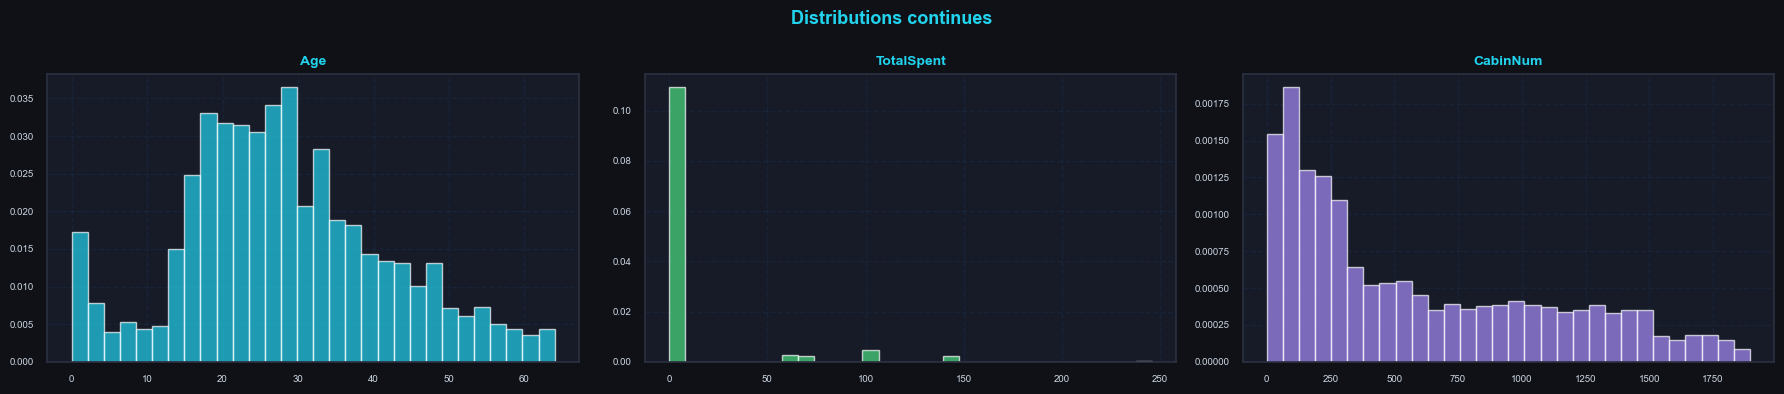

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.patch.set_facecolor(COLORS['bg'])
fig.suptitle("Distributions continues", fontsize=13, fontweight='bold', color=COLORS['cyan'])

for ax, (col, color) in zip(axes, [
    ('Age',        COLORS['cyan']),
    ('TotalSpent', COLORS['green']),
    ('CabinNum',   COLORS['purple']),
]):
    vals = train_data[col].dropna().astype(float)
    ax.hist(vals, bins=30, color=color, alpha=0.7, density=True)
    ax.set_title(col, fontsize=10, fontweight='bold', color=COLORS['cyan'])
    ax.tick_params(labelsize=7, colors=COLORS['text'])
    ax.set_facecolor(COLORS['bg2'])
    for spine in ax.spines.values():
        spine.set_edgecolor(COLORS['border'])

plt.tight_layout()
plt.show()


In [16]:
exp_cols   = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
exp_colors = [COLORS['amber'], COLORS['red'], COLORS['blue'], COLORS['teal'], COLORS['pink']]

service_totals = train_data[exp_cols].sum()
total          = service_totals.sum()

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(COLORS['bg'])
ax.set_facecolor(COLORS['bg2'])

left = 0
for col, color in zip(exp_cols, exp_colors):
    val = service_totals[col]
    pct = 100 * val / total
    ax.barh('Total dépenses', val, left=left, color=color, alpha=0.85, label=f"{col} ({pct:.1f}%)")
    ax.text(left + val / 2, 0, f"{pct:.1f}%",
            ha='center', va='center', fontsize=9, fontweight='bold',
            color='#0f1117')
    left += val

ax.set_title("Répartition des dépenses totales par service",
             fontsize=13, fontweight='bold', color=COLORS['cyan'])
ax.tick_params(labelsize=8, colors=COLORS['text'])
ax.legend(fontsize=9, facecolor=COLORS['bg3'], edgecolor=COLORS['border'],
          labelcolor=COLORS['text'], loc='upper right',
          bbox_to_anchor=(1, 1.25), ncol=3)
ax.set_xlabel("Montant total (€)", fontsize=10, color=COLORS['text'])
for spine in ax.spines.values():
    spine.set_edgecolor(COLORS['border'])

plt.tight_layout(
plt.show()



SyntaxError: incomplete input (775148351.py, line 33)

### 2.1.2 Variables catégorielles 

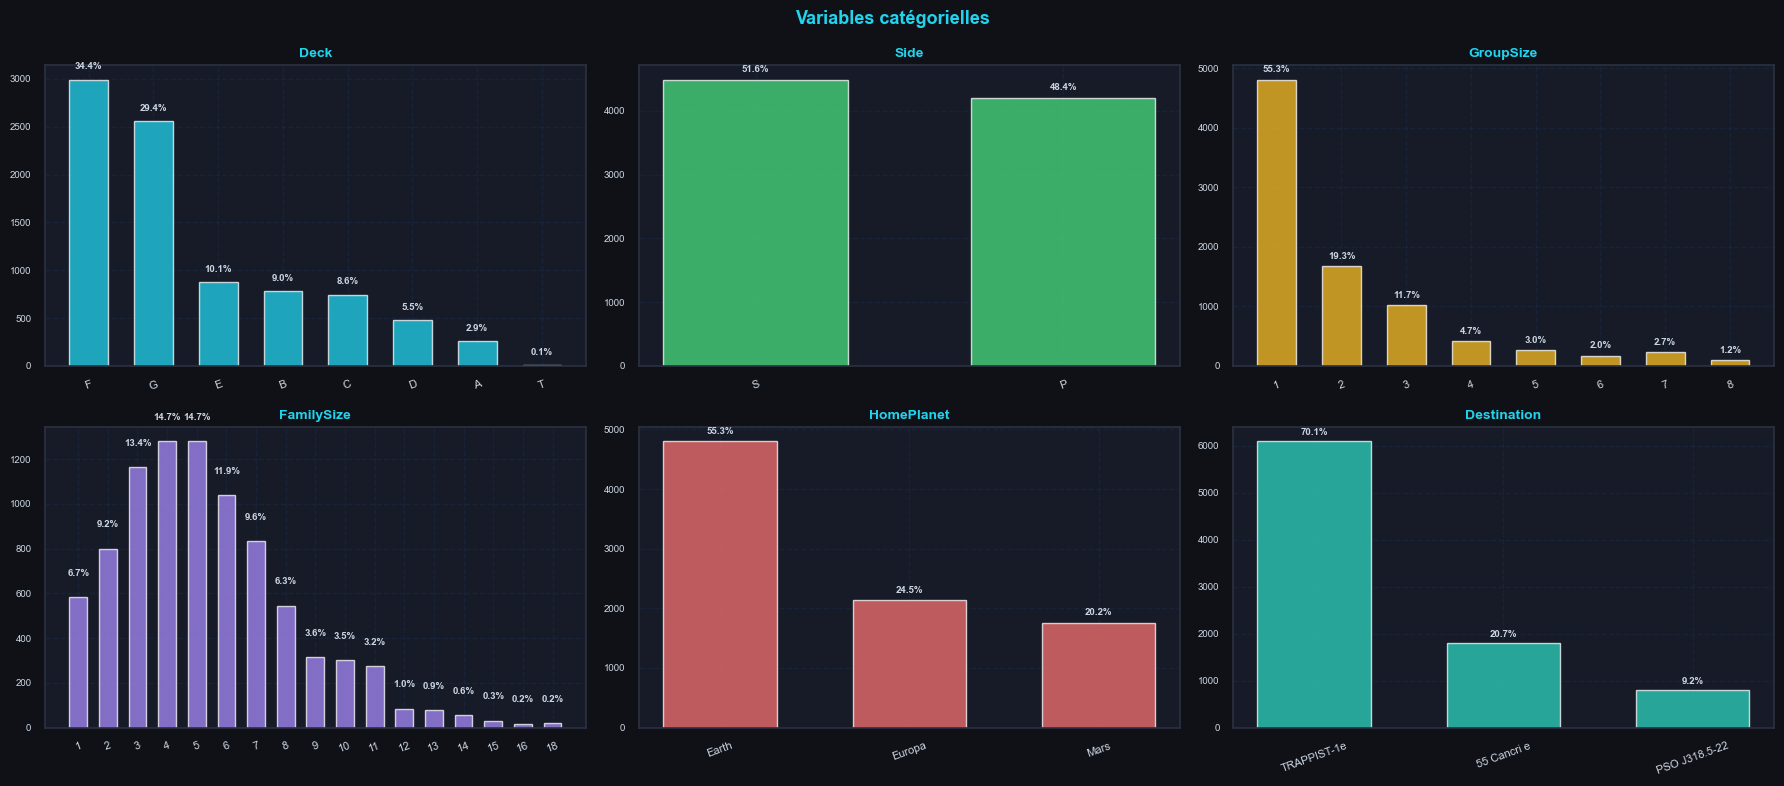

In [ ]:
cat_configs = [
    ('Deck',        COLORS['cyan'],   train_data['Deck'].value_counts().index),
    ('Side',        COLORS['green'],  train_data['Side'].value_counts().index),
    ('GroupSize',   COLORS['amber'],  sorted(train_data['GroupSize'].dropna().unique())),
    ('FamilySize',  COLORS['purple'], sorted(train_data['FamilySize'].dropna().unique())),
    ('HomePlanet',  COLORS['red'],    train_data['HomePlanet'].value_counts().index),
    ('Destination', COLORS['teal'],   train_data['Destination'].value_counts().index),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.patch.set_facecolor(COLORS['bg'])
fig.suptitle("Variables catégorielles", fontsize=13, fontweight='bold', color=COLORS['cyan'])

for ax, (col, color, order) in zip(axes.flatten(), cat_configs):
    counts = train_data[col].value_counts().reindex(order).fillna(0)
    total_n = counts.sum()
    bars = ax.bar(counts.index.astype(str), counts.values, color=color, alpha=0.75, width=0.6)
    for bar, val in zip(bars, counts.values):
        pct = 100 * val / total_n
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + total_n * 0.01,
                f"{pct:.1f}%",
                ha='center', va='bottom', fontsize=7,
                color=COLORS['text'], fontweight='bold')
    ax.set_title(col, fontsize=10, fontweight='bold', color=COLORS['cyan'])
    ax.tick_params(labelsize=8, axis='x', rotation=20, colors=COLORS['text'])
    ax.tick_params(labelsize=7, axis='y', colors=COLORS['text'])
    ax.set_facecolor(COLORS['bg2'])
    for spine in ax.spines.values():
        spine.set_edgecolor(COLORS['border'])

plt.tight_layout()
plt.show()

### 2.1.3 Variables binaires

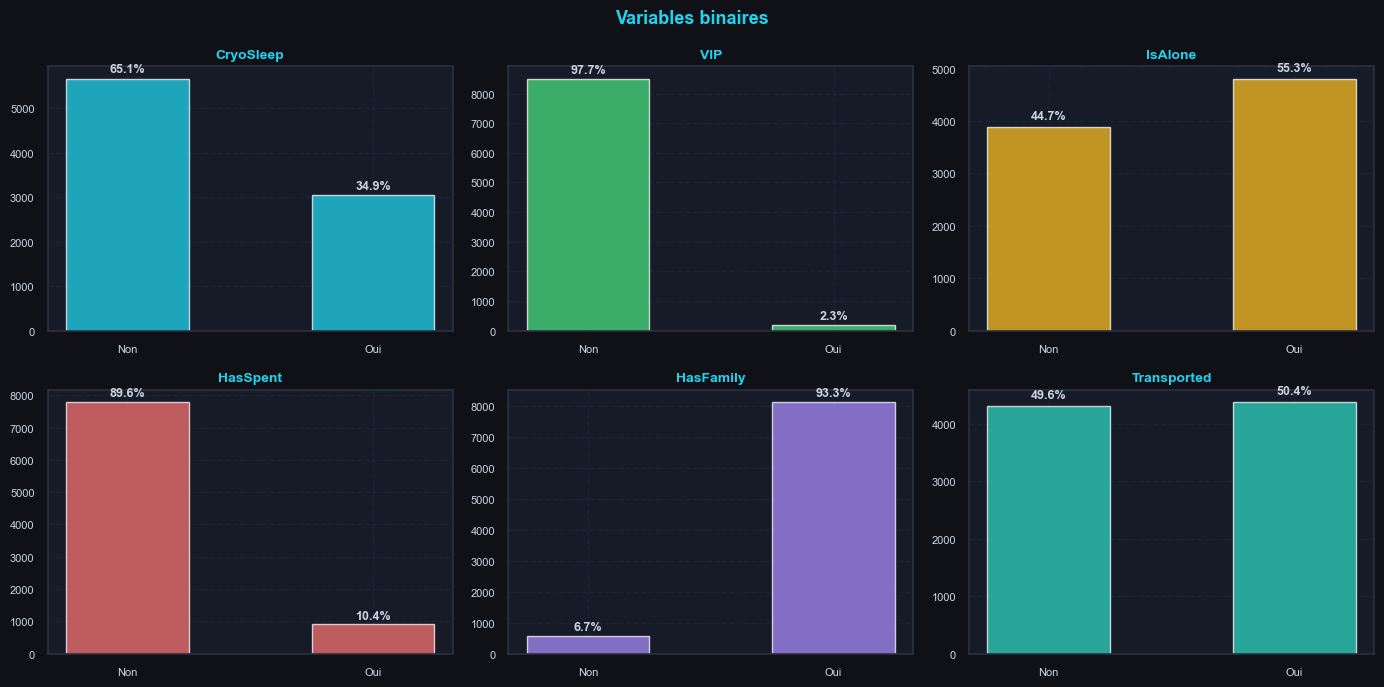

In [ ]:
binary_vars = ['CryoSleep', 'VIP', 'IsAlone', 'HasSpent', 'HasFamily', 'Transported']
bin_colors  = [COLORS['cyan'], COLORS['green'], COLORS['amber'],
               COLORS['red'],  COLORS['purple'], COLORS['teal']]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.patch.set_facecolor(COLORS['bg'])
fig.suptitle("Variables binaires", fontsize=13, fontweight='bold', color=COLORS['cyan'])

for ax, col, color in zip(axes.flatten(), binary_vars, bin_colors):
    counts  = train_data[col].value_counts().sort_index()
    total_n = counts.sum()
    labels  = ['Non' if str(v) == '0' else 'Oui' for v in counts.index]
    bars    = ax.bar(labels, counts.values, color=color, alpha=0.75, width=0.5)
    for bar, val in zip(bars, counts.values):
        pct = 100 * val / total_n
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + total_n * 0.01,
                f"{pct:.1f}%",
                ha='center', va='bottom', fontsize=9,
                color=COLORS['text'], fontweight='bold')
    ax.set_title(col, fontsize=10, fontweight='bold', color=COLORS['cyan'])
    ax.tick_params(labelsize=8, colors=COLORS['text'])
    ax.set_facecolor(COLORS['bg2'])
    for spine in ax.spines.values():
        spine.set_edgecolor(COLORS['border'])

plt.tight_layout()
plt.show()

## 2.2 Statistiques bivariées 

Verification de la coherence des données (cryogénisé et depenses)

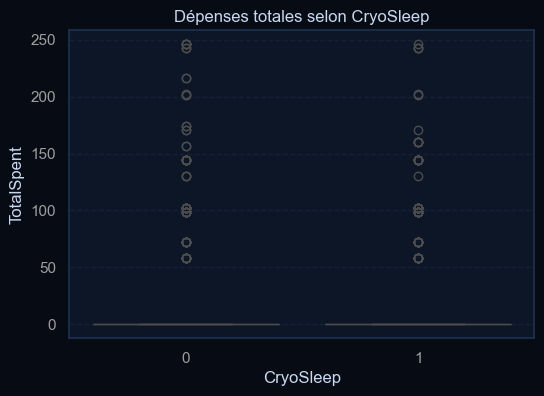

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=train_data, x='CryoSleep', y='TotalSpent')
plt.title("Dépenses totales selon CryoSleep")
plt.show()


Analyse des relations entre variables catégorielles avec le V de Cramer

Nous analysons la force des relations entre les variables catégorielles à l'aide du V de Cramer et visualisons la matrice de corrélation obtenue. La diagonale est fixée à 1 pour une meilleure lisibilité.

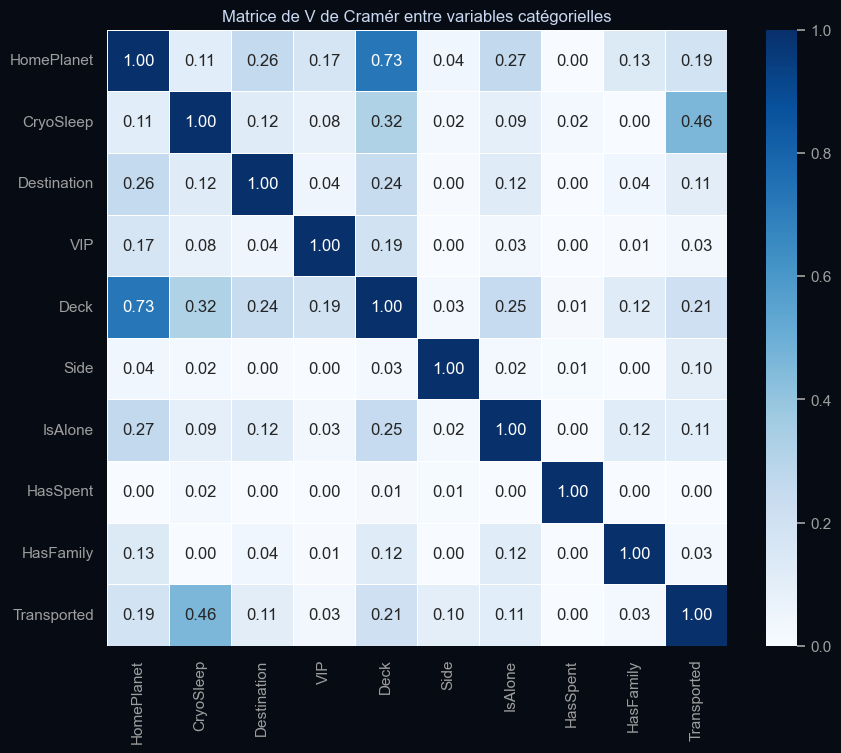

In [ ]:
# SELECTION DES VARIABLES CATEGORIELLES
cat_cols = [
    'HomePlanet',
    'CryoSleep',
    'Destination',
    'VIP',
    'Deck',
    'Side',
    'IsAlone',
    'HasSpent',
    'HasFamily',
    'Transported'
]

# FONCTION V DE CRAMER

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))


# CALCUL DE LA MATRICE DE V DE CRAMER

cramer_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols)

for col1 in cat_cols:
    for col2 in cat_cols:
        cramer_matrix.loc[col1, col2] = cramers_v(train_data[col1], train_data[col2])

cramer_matrix = cramer_matrix.astype(float)
np.fill_diagonal(cramer_matrix.values, 1)


# HEATMAP

plt.figure(figsize=(10, 8))
sns.heatmap(
    cramer_matrix,
    annot=True,
    cmap='Blues',
    fmt='.2f',
    linewidths=0.5
)
plt.title("Matrice de V de Cramér entre variables catégorielles")
plt.show()

### 2.4 Croisements pertinents & Hypothèses

On croise les variables les plus discriminantes pour formuler des hypothèses interprétables.


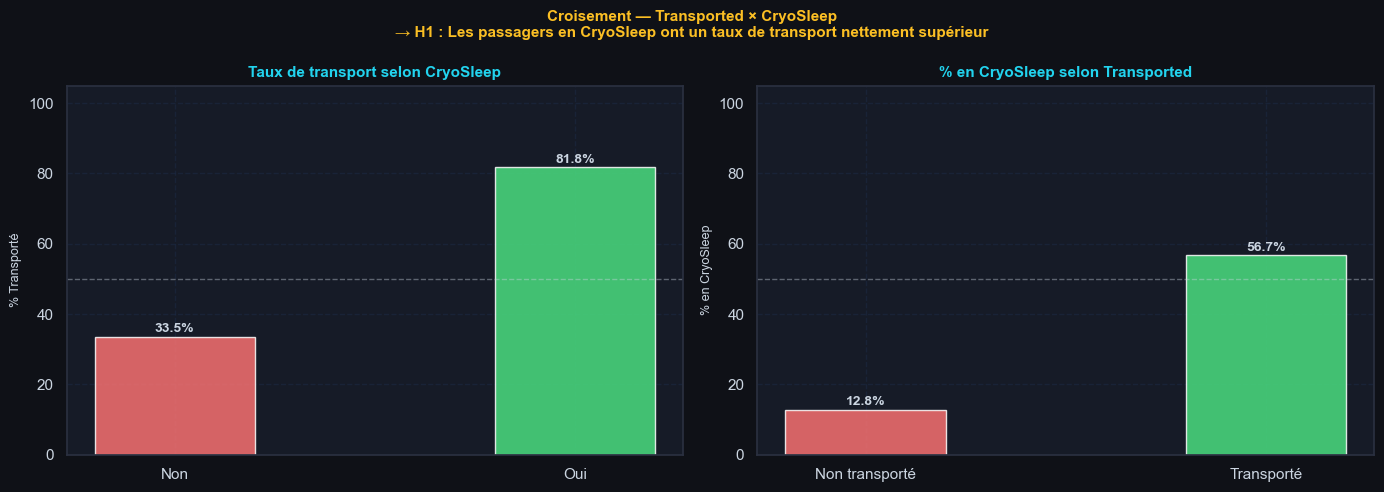

✓ Transported × CryoSleep :
              n  transport_rate
CryoSleep                      
0          5656           0.335
1          3037           0.818


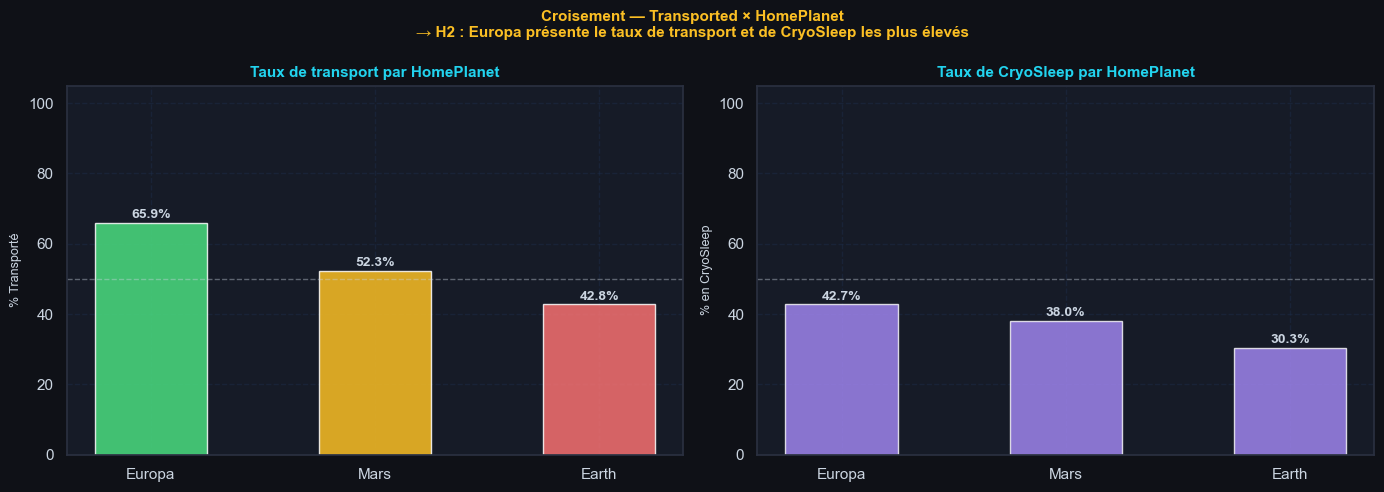

✓ Transported × HomePlanet :
               n  transport_rate  cryo_rate
HomePlanet                                 
Europa      2131           0.659      0.427
Mars        1759           0.523      0.380
Earth       4803           0.428      0.303


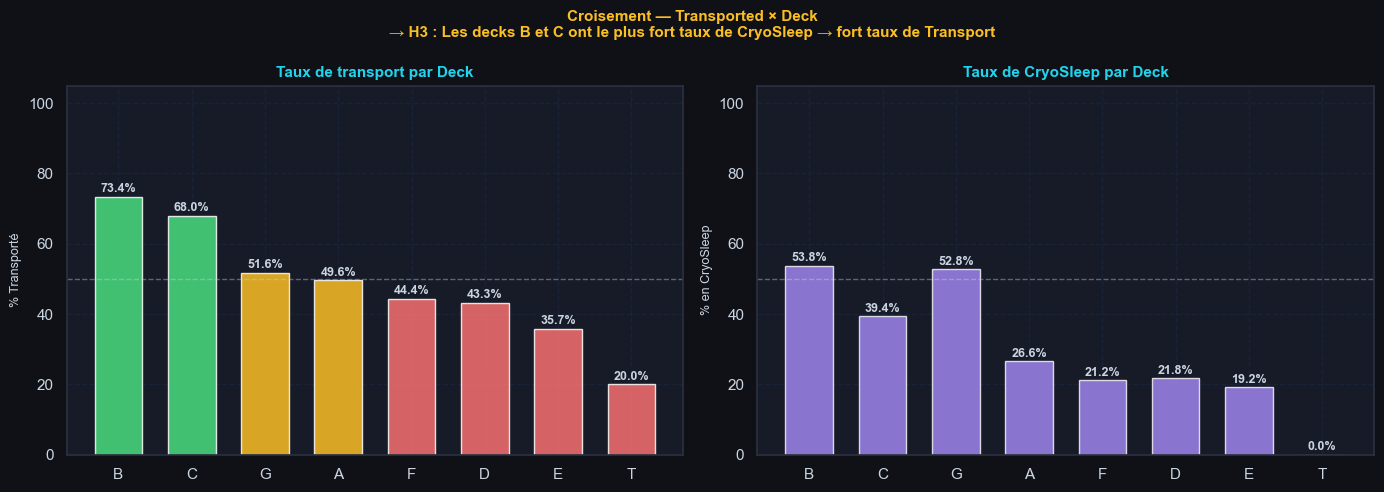

✓ Transported × Deck :
         n  transport_rate  cryo_rate
Deck                                 
B      779           0.734      0.538
C      747           0.680      0.394
G     2559           0.516      0.528
A      256           0.496      0.266
F     2993           0.444      0.212
D      478           0.433      0.218
E      876           0.357      0.192
T        5           0.200      0.000


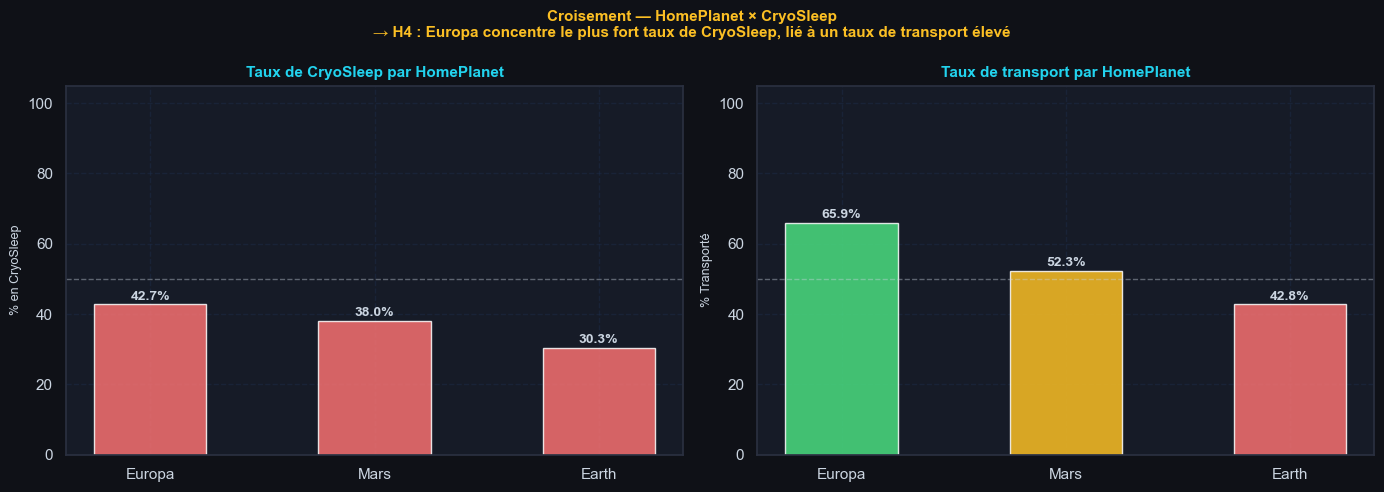

✓ HomePlanet × CryoSleep :
               n  cryo_rate  transport_rate
HomePlanet                                 
Europa      2131      0.427           0.659
Mars        1759      0.380           0.523
Earth       4803      0.303           0.428


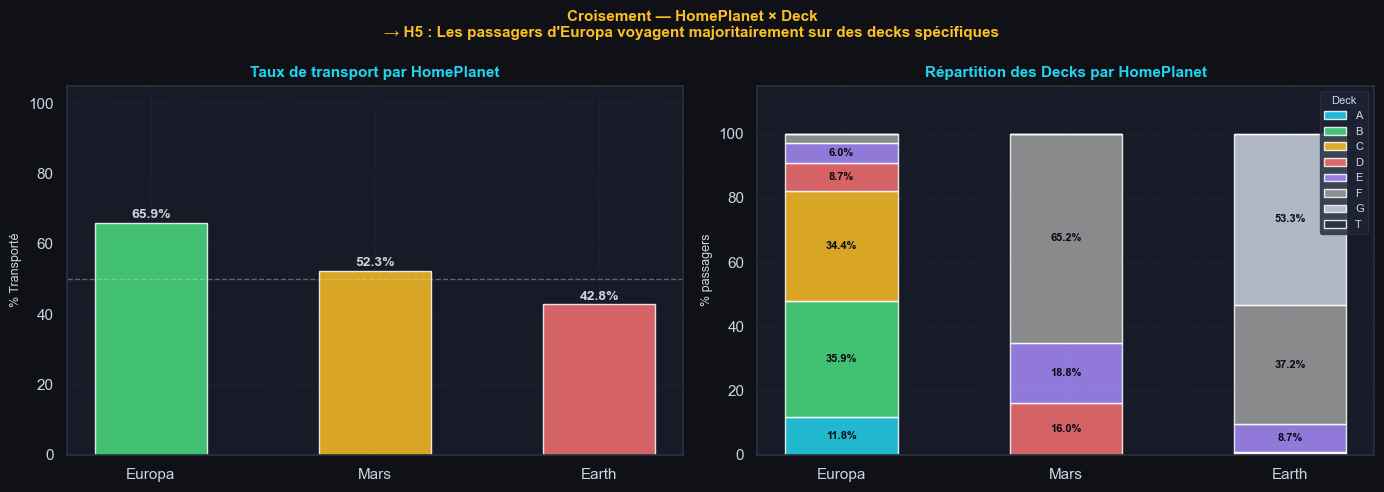

✓ HomePlanet × Deck :
               n  transport_rate deck_mode
HomePlanet                                
Europa      2131           0.659         B
Mars        1759           0.523         F
Earth       4803           0.428         G


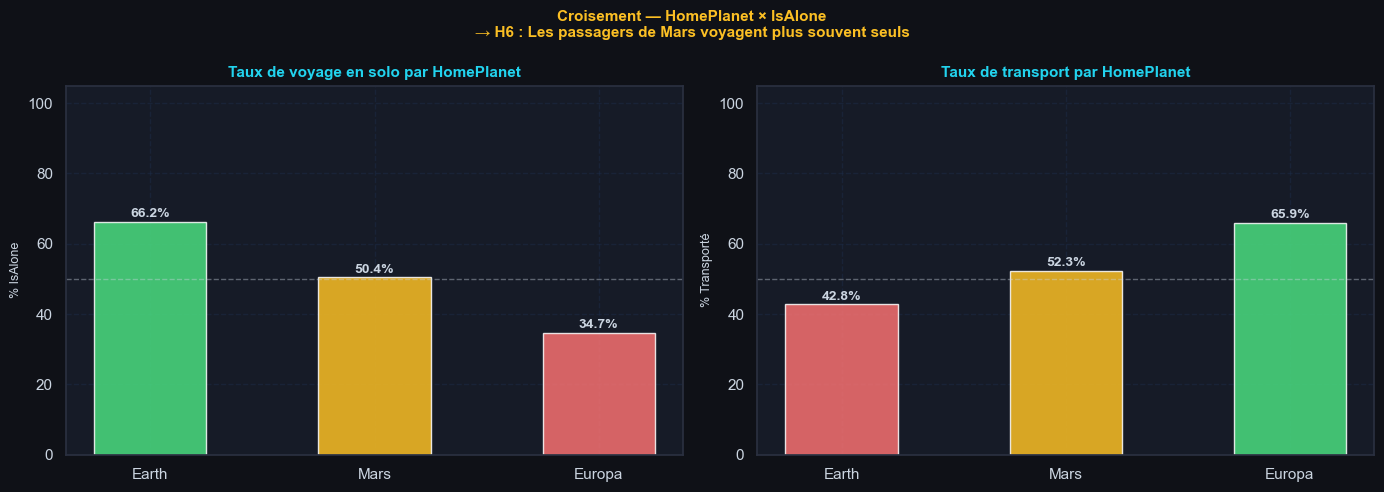

✓ HomePlanet × IsAlone :
               n  alone_rate  transport_rate
HomePlanet                                  
Earth       4803       0.662           0.428
Mars        1759       0.504           0.523
Europa      2131       0.347           0.659


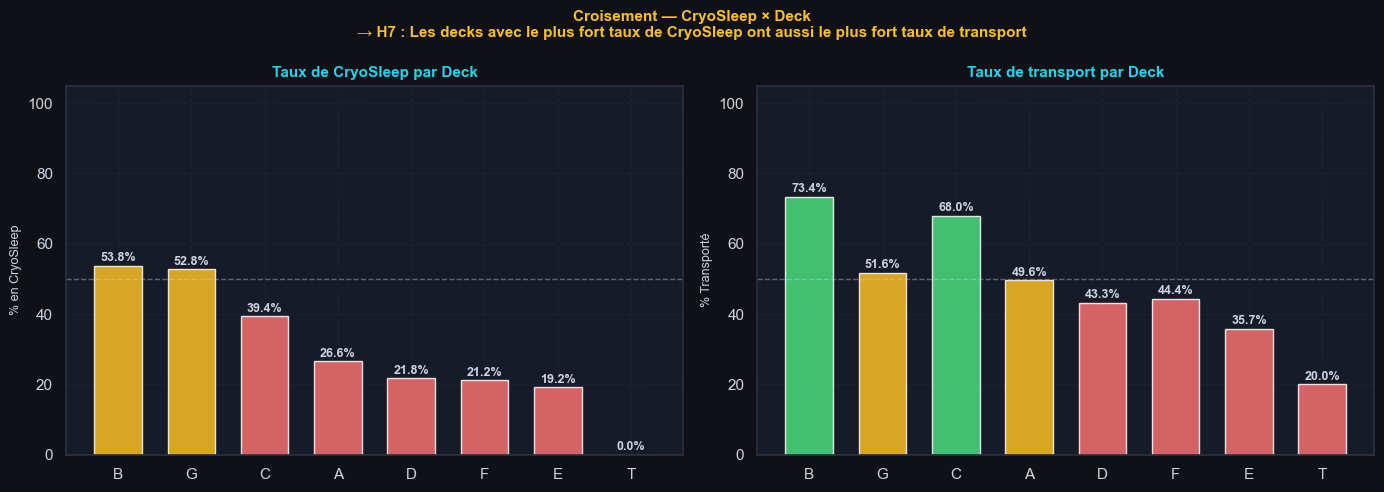

✓ CryoSleep × Deck :
         n  cryo_rate  transport_rate
Deck                                 
B      779      0.538           0.734
G     2559      0.528           0.516
C      747      0.394           0.680
A      256      0.266           0.496
D      478      0.218           0.433
F     2993      0.212           0.444
E      876      0.192           0.357
T        5      0.000           0.200


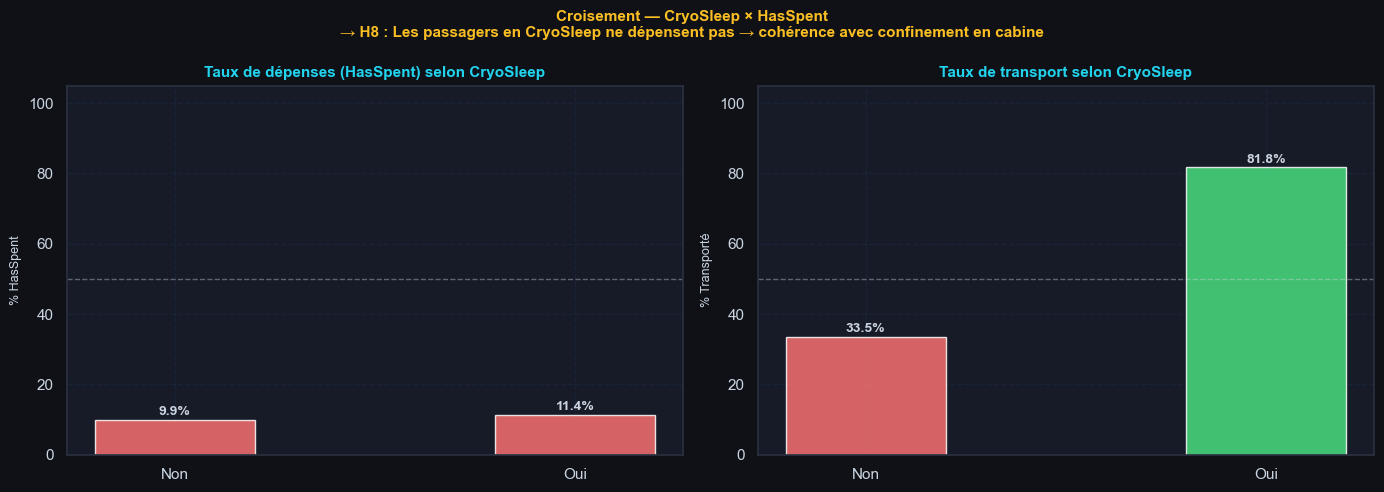

✓ CryoSleep × HasSpent :
              n  spent_rate  transport_rate
CryoSleep                                  
0          5656       0.099           0.335
1          3037       0.114           0.818


In [ ]:
# CROISEMENTS : Transported × (CryoSleep, HomePlanet, Deck)


# ── Transported × CryoSleep ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(COLORS['bg'])
for ax in axes:
    ax.set_facecolor(COLORS['bg2'])

cryo_stats = train_data.groupby('CryoSleep').agg(
    transport_rate=('Transported', 'mean'),
    n=('Transported', 'count')
)  

colors_cryo = [COLORS['green'] if v >= 0.6 else COLORS['amber'] if v >= 0.45
               else COLORS['red'] for v in cryo_stats['transport_rate']]

bars = axes[0].bar(range(len(cryo_stats)), cryo_stats['transport_rate'] * 100,
                   color=colors_cryo, alpha=0.85, width=0.4)
axes[0].axhline(50, color=COLORS['text'], linestyle='--', linewidth=1, alpha=0.4)
axes[0].set_xticks(range(len(cryo_stats)))
axes[0].set_xticklabels(['Non' if str(v) == '0' else 'Oui' for v in cryo_stats.index],
                         color=COLORS['text'])
for bar, val in zip(bars, cryo_stats['transport_rate'] * 100):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=10, color=COLORS['text'], fontweight='bold')
axes[0].set_title("Taux de transport selon CryoSleep",
                  fontsize=11, fontweight='bold', color=COLORS['cyan'])
axes[0].set_ylabel("% Transporté", fontsize=9, color=COLORS['text'])
axes[0].set_ylim(0, 105)
axes[0].tick_params(colors=COLORS['text'])
for spine in axes[0].spines.values():
    spine.set_edgecolor(COLORS['border'])

cryo_transp = train_data.groupby('Transported')['CryoSleep'].mean() * 100
colors_t = ['Non' if str(v) == '0' else 'Oui' for v in cryo_transp.index]
bar_colors_t = [COLORS['red'], COLORS['green']]
bars2 = axes[1].bar(['Non transporté', 'Transporté'], cryo_transp.values,
                    color=bar_colors_t, alpha=0.85, width=0.4)
axes[1].axhline(50, color=COLORS['text'], linestyle='--', linewidth=1, alpha=0.4)
for bar, val in zip(bars2, cryo_transp.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=10, color=COLORS['text'], fontweight='bold')
axes[1].set_title("% en CryoSleep selon Transported",
                  fontsize=11, fontweight='bold', color=COLORS['cyan'])
axes[1].set_ylabel("% en CryoSleep", fontsize=9, color=COLORS['text'])
axes[1].set_ylim(0, 105)
axes[1].tick_params(colors=COLORS['text'])
for spine in axes[1].spines.values():
    spine.set_edgecolor(COLORS['border'])

fig.suptitle("Croisement — Transported × CryoSleep\n"
             "→ H1 : Les passagers en CryoSleep ont un taux de transport nettement supérieur",
             fontsize=11, fontweight='bold', color=COLORS['amber'])
plt.tight_layout()

plt.show()
print("✓ Transported × CryoSleep :")
print(cryo_stats[['n', 'transport_rate']].round(3).to_string())


# ── Transported × HomePlanet ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(COLORS['bg'])
for ax in axes:
    ax.set_facecolor(COLORS['bg2'])

planet_stats = train_data.groupby('HomePlanet').agg(
    transport_rate=('Transported', 'mean'),
    n=('Transported', 'count'),
    cryo_rate=('CryoSleep', 'mean')
).sort_values('transport_rate', ascending=False)

colors_planet = [COLORS['green'] if v >= 0.6 else COLORS['amber'] if v >= 0.45
                 else COLORS['red'] for v in planet_stats['transport_rate']]

bars = axes[0].bar(range(len(planet_stats)), planet_stats['transport_rate'] * 100,
                   color=colors_planet, alpha=0.85, width=0.5)
axes[0].axhline(50, color=COLORS['text'], linestyle='--', linewidth=1, alpha=0.4)
axes[0].set_xticks(range(len(planet_stats)))
axes[0].set_xticklabels(planet_stats.index, color=COLORS['text'])
for bar, val in zip(bars, planet_stats['transport_rate'] * 100):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=10, color=COLORS['text'], fontweight='bold')
axes[0].set_title("Taux de transport par HomePlanet",
                  fontsize=11, fontweight='bold', color=COLORS['cyan'])
axes[0].set_ylabel("% Transporté", fontsize=9, color=COLORS['text'])
axes[0].set_ylim(0, 105)
axes[0].tick_params(colors=COLORS['text'])
for spine in axes[0].spines.values():
    spine.set_edgecolor(COLORS['border'])

bars2 = axes[1].bar(range(len(planet_stats)), planet_stats['cryo_rate'] * 100,
                    color=COLORS['purple'], alpha=0.8, width=0.5)
axes[1].axhline(50, color=COLORS['text'], linestyle='--', linewidth=1, alpha=0.4)
axes[1].set_xticks(range(len(planet_stats)))
axes[1].set_xticklabels(planet_stats.index, color=COLORS['text'])
for bar, val in zip(bars2, planet_stats['cryo_rate'] * 100):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=10, color=COLORS['text'], fontweight='bold')
axes[1].set_title("Taux de CryoSleep par HomePlanet",
                  fontsize=11, fontweight='bold', color=COLORS['cyan'])
axes[1].set_ylabel("% en CryoSleep", fontsize=9, color=COLORS['text'])
axes[1].set_ylim(0, 105)
axes[1].tick_params(colors=COLORS['text'])
for spine in axes[1].spines.values():
    spine.set_edgecolor(COLORS['border'])

fig.suptitle("Croisement — Transported × HomePlanet\n"
             "→ H2 : Europa présente le taux de transport et de CryoSleep les plus élevés",
             fontsize=11, fontweight='bold', color=COLORS['amber'])
plt.tight_layout()
plt.show()
print("✓ Transported × HomePlanet :")
print(planet_stats[['n', 'transport_rate', 'cryo_rate']].round(3).to_string())


# ── Transported × Deck ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(COLORS['bg'])
for ax in axes:
    ax.set_facecolor(COLORS['bg2'])

deck_stats = train_data.groupby('Deck').agg(
    transport_rate=('Transported', 'mean'),
    n=('Transported', 'count'),
    cryo_rate=('CryoSleep', 'mean')
).sort_values('transport_rate', ascending=False)

colors_deck = [COLORS['green'] if v >= 0.6 else COLORS['amber'] if v >= 0.45
               else COLORS['red'] for v in deck_stats['transport_rate']]

bars = axes[0].bar(range(len(deck_stats)), deck_stats['transport_rate'] * 100,
                   color=colors_deck, alpha=0.85, width=0.65)
axes[0].axhline(50, color=COLORS['text'], linestyle='--', linewidth=1, alpha=0.4)
axes[0].set_xticks(range(len(deck_stats)))
axes[0].set_xticklabels(deck_stats.index, color=COLORS['text'])
for bar, val in zip(bars, deck_stats['transport_rate'] * 100):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=9, color=COLORS['text'], fontweight='bold')
axes[0].set_title("Taux de transport par Deck",
                  fontsize=11, fontweight='bold', color=COLORS['cyan'])
axes[0].set_ylabel("% Transporté", fontsize=9, color=COLORS['text'])
axes[0].set_ylim(0, 105)
axes[0].tick_params(colors=COLORS['text'])
for spine in axes[0].spines.values():
    spine.set_edgecolor(COLORS['border'])

bars2 = axes[1].bar(range(len(deck_stats)), deck_stats['cryo_rate'] * 100,
                    color=COLORS['purple'], alpha=0.8, width=0.65)
axes[1].axhline(50, color=COLORS['text'], linestyle='--', linewidth=1, alpha=0.4)
axes[1].set_xticks(range(len(deck_stats)))
axes[1].set_xticklabels(deck_stats.index, color=COLORS['text'])
for bar, val in zip(bars2, deck_stats['cryo_rate'] * 100):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=9, color=COLORS['text'], fontweight='bold')
axes[1].set_title("Taux de CryoSleep par Deck",
                  fontsize=11, fontweight='bold', color=COLORS['cyan'])
axes[1].set_ylabel("% en CryoSleep", fontsize=9, color=COLORS['text'])
axes[1].set_ylim(0, 105)
axes[1].tick_params(colors=COLORS['text'])
for spine in axes[1].spines.values():
    spine.set_edgecolor(COLORS['border'])

fig.suptitle("Croisement — Transported × Deck\n"
             "→ H3 : Les decks B et C ont le plus fort taux de CryoSleep → fort taux de Transport",
             fontsize=11, fontweight='bold', color=COLORS['amber'])
plt.tight_layout()
plt.show()
print("✓ Transported × Deck :")
print(deck_stats[['n', 'transport_rate', 'cryo_rate']].round(3).to_string())



# CROISEMENTS — HomePlanet × (CryoSleep, Deck, IsAlone)

# ── HomePlanet × CryoSleep ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(COLORS['bg'])
for ax in axes:
    ax.set_facecolor(COLORS['bg2'])

hp_cryo_stats = train_data.groupby('HomePlanet').agg(
    cryo_rate=('CryoSleep', 'mean'),
    n=('CryoSleep', 'count'),
    transport_rate=('Transported', 'mean')
).sort_values('cryo_rate', ascending=False)

colors_hp_cryo = [COLORS['green'] if v >= 0.6 else COLORS['amber'] if v >= 0.45
                  else COLORS['red'] for v in hp_cryo_stats['cryo_rate']]

bars = axes[0].bar(range(len(hp_cryo_stats)), hp_cryo_stats['cryo_rate'] * 100,
                   color=colors_hp_cryo, alpha=0.85, width=0.5)
axes[0].axhline(50, color=COLORS['text'], linestyle='--', linewidth=1, alpha=0.4)
axes[0].set_xticks(range(len(hp_cryo_stats)))
axes[0].set_xticklabels(hp_cryo_stats.index, color=COLORS['text'])
for bar, val in zip(bars, hp_cryo_stats['cryo_rate'] * 100):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=10, color=COLORS['text'], fontweight='bold')
axes[0].set_title("Taux de CryoSleep par HomePlanet",
                  fontsize=11, fontweight='bold', color=COLORS['cyan'])
axes[0].set_ylabel("% en CryoSleep", fontsize=9, color=COLORS['text'])
axes[0].set_ylim(0, 105)
axes[0].tick_params(colors=COLORS['text'])
for spine in axes[0].spines.values():
    spine.set_edgecolor(COLORS['border'])

colors_hp_t = [COLORS['green'] if v >= 0.6 else COLORS['amber'] if v >= 0.45
               else COLORS['red'] for v in hp_cryo_stats['transport_rate']]
bars2 = axes[1].bar(range(len(hp_cryo_stats)), hp_cryo_stats['transport_rate'] * 100,
                    color=colors_hp_t, alpha=0.85, width=0.5)
axes[1].axhline(50, color=COLORS['text'], linestyle='--', linewidth=1, alpha=0.4)
axes[1].set_xticks(range(len(hp_cryo_stats)))
axes[1].set_xticklabels(hp_cryo_stats.index, color=COLORS['text'])
for bar, val in zip(bars2, hp_cryo_stats['transport_rate'] * 100):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=10, color=COLORS['text'], fontweight='bold')
axes[1].set_title("Taux de transport par HomePlanet",
                  fontsize=11, fontweight='bold', color=COLORS['cyan'])
axes[1].set_ylabel("% Transporté", fontsize=9, color=COLORS['text'])
axes[1].set_ylim(0, 105)
axes[1].tick_params(colors=COLORS['text'])
for spine in axes[1].spines.values():
    spine.set_edgecolor(COLORS['border'])

fig.suptitle("Croisement — HomePlanet × CryoSleep\n"
             "→ H4 : Europa concentre le plus fort taux de CryoSleep, lié à un taux de transport élevé",
             fontsize=11, fontweight='bold', color=COLORS['amber'])
plt.tight_layout()
plt.show()
print("✓ HomePlanet × CryoSleep :")
print(hp_cryo_stats[['n', 'cryo_rate', 'transport_rate']].round(3).to_string())


# ── HomePlanet × Deck ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(COLORS['bg'])
for ax in axes:
    ax.set_facecolor(COLORS['bg2'])

hp_deck_stats = train_data.groupby('HomePlanet').agg(
    transport_rate=('Transported', 'mean'),
    n=('Transported', 'count'),
    deck_mode=('Deck', lambda x: x.mode()[0])
).sort_values('transport_rate', ascending=False)

hp_deck_pct = (train_data.groupby(['HomePlanet', 'Deck'])
               .size().unstack(fill_value=0)
               .reindex(hp_deck_stats.index))
hp_deck_pct = hp_deck_pct.div(hp_deck_pct.sum(axis=1), axis=0) * 100

# ✅ Uniquement des couleurs présentes dans ton COLORS
deck_colors = [COLORS['cyan'], COLORS['green'], COLORS['amber'], COLORS['red'],
               COLORS['purple'], COLORS['muted'], COLORS['text'], COLORS['border']]

colors_hp_d = [COLORS['green'] if v >= 0.6 else COLORS['amber'] if v >= 0.45
               else COLORS['red'] for v in hp_deck_stats['transport_rate']]
bars = axes[0].bar(range(len(hp_deck_stats)), hp_deck_stats['transport_rate'] * 100,
                   color=colors_hp_d, alpha=0.85, width=0.5)
axes[0].axhline(50, color=COLORS['text'], linestyle='--', linewidth=1, alpha=0.4)
axes[0].set_xticks(range(len(hp_deck_stats)))
axes[0].set_xticklabels(hp_deck_stats.index, color=COLORS['text'])
for bar, val in zip(bars, hp_deck_stats['transport_rate'] * 100):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=10, color=COLORS['text'], fontweight='bold')
axes[0].set_title("Taux de transport par HomePlanet",
                  fontsize=11, fontweight='bold', color=COLORS['cyan'])
axes[0].set_ylabel("% Transporté", fontsize=9, color=COLORS['text'])
axes[0].set_ylim(0, 105)
axes[0].tick_params(colors=COLORS['text'])
for spine in axes[0].spines.values():
    spine.set_edgecolor(COLORS['border'])

bottom = np.zeros(len(hp_deck_pct))
for i, deck in enumerate(hp_deck_pct.columns):
    color = deck_colors[i % len(deck_colors)]
    bars2 = axes[1].bar(range(len(hp_deck_pct)), hp_deck_pct[deck],
                        bottom=bottom, color=color, alpha=0.85, width=0.5, label=deck)
    for bar, val, bot in zip(bars2, hp_deck_pct[deck], bottom):
        if val > 5:
            axes[1].text(bar.get_x() + bar.get_width() / 2, bot + val / 2,
                         f'{val:.1f}%', ha='center', va='center',
                         fontsize=8, color='#070b14', fontweight='bold')
    bottom += hp_deck_pct[deck].values

axes[1].set_xticks(range(len(hp_deck_pct)))
axes[1].set_xticklabels(hp_deck_pct.index, color=COLORS['text'])
axes[1].set_title("Répartition des Decks par HomePlanet",
                  fontsize=11, fontweight='bold', color=COLORS['cyan'])
axes[1].set_ylabel("% passagers", fontsize=9, color=COLORS['text'])
axes[1].set_ylim(0, 115)
axes[1].tick_params(colors=COLORS['text'])
axes[1].legend(title='Deck', fontsize=8, title_fontsize=8,
               facecolor=COLORS['bg3'], edgecolor=COLORS['border'],
               labelcolor=COLORS['text'], loc='upper right')
for spine in axes[1].spines.values():
    spine.set_edgecolor(COLORS['border'])

fig.suptitle("Croisement — HomePlanet × Deck\n"
             "→ H5 : Les passagers d'Europa voyagent majoritairement sur des decks spécifiques",
             fontsize=11, fontweight='bold', color=COLORS['amber'])
plt.tight_layout()
plt.show()
print("✓ HomePlanet × Deck :")
print(hp_deck_stats[['n', 'transport_rate', 'deck_mode']].round(3).to_string())


# ── HomePlanet × IsAlone ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(COLORS['bg'])
for ax in axes:
    ax.set_facecolor(COLORS['bg2'])

hp_alone_stats = train_data.groupby('HomePlanet').agg(
    alone_rate=('IsAlone', 'mean'),
    n=('IsAlone', 'count'),
    transport_rate=('Transported', 'mean')
).sort_values('alone_rate', ascending=False)

colors_alone = [COLORS['green'] if v >= 0.6 else COLORS['amber'] if v >= 0.45
                else COLORS['red'] for v in hp_alone_stats['alone_rate']]

bars = axes[0].bar(range(len(hp_alone_stats)), hp_alone_stats['alone_rate'] * 100,
                   color=colors_alone, alpha=0.85, width=0.5)
axes[0].axhline(50, color=COLORS['text'], linestyle='--', linewidth=1, alpha=0.4)
axes[0].set_xticks(range(len(hp_alone_stats)))
axes[0].set_xticklabels(hp_alone_stats.index, color=COLORS['text'])
for bar, val in zip(bars, hp_alone_stats['alone_rate'] * 100):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=10, color=COLORS['text'], fontweight='bold')
axes[0].set_title("Taux de voyage en solo par HomePlanet",
                  fontsize=11, fontweight='bold', color=COLORS['cyan'])
axes[0].set_ylabel("% IsAlone", fontsize=9, color=COLORS['text'])
axes[0].set_ylim(0, 105)
axes[0].tick_params(colors=COLORS['text'])
for spine in axes[0].spines.values():
    spine.set_edgecolor(COLORS['border'])

colors_hp_t2 = [COLORS['green'] if v >= 0.6 else COLORS['amber'] if v >= 0.45
                else COLORS['red'] for v in hp_alone_stats['transport_rate']]
bars2 = axes[1].bar(range(len(hp_alone_stats)), hp_alone_stats['transport_rate'] * 100,
                    color=colors_hp_t2, alpha=0.85, width=0.5)
axes[1].axhline(50, color=COLORS['text'], linestyle='--', linewidth=1, alpha=0.4)
axes[1].set_xticks(range(len(hp_alone_stats)))
axes[1].set_xticklabels(hp_alone_stats.index, color=COLORS['text'])
for bar, val in zip(bars2, hp_alone_stats['transport_rate'] * 100):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=10, color=COLORS['text'], fontweight='bold')
axes[1].set_title("Taux de transport par HomePlanet",
                  fontsize=11, fontweight='bold', color=COLORS['cyan'])
axes[1].set_ylabel("% Transporté", fontsize=9, color=COLORS['text'])
axes[1].set_ylim(0, 105)
axes[1].tick_params(colors=COLORS['text'])
for spine in axes[1].spines.values():
    spine.set_edgecolor(COLORS['border'])

fig.suptitle("Croisement — HomePlanet × IsAlone\n"
             "→ H6 : Les passagers de Mars voyagent plus souvent seuls",
             fontsize=11, fontweight='bold', color=COLORS['amber'])
plt.tight_layout()
plt.show()
print("✓ HomePlanet × IsAlone :")
print(hp_alone_stats[['n', 'alone_rate', 'transport_rate']].round(3).to_string())



# CROISEMENTS — CryoSleep × (Deck, HasSpent)

# ── CryoSleep × Deck ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(COLORS['bg'])
for ax in axes:
    ax.set_facecolor(COLORS['bg2'])

cryo_deck_stats = train_data.groupby('Deck').agg(
    cryo_rate=('CryoSleep', 'mean'),
    n=('CryoSleep', 'count'),
    transport_rate=('Transported', 'mean')
).sort_values('cryo_rate', ascending=False)

colors_cryo_deck = [COLORS['green'] if v >= 0.6 else COLORS['amber'] if v >= 0.45
                    else COLORS['red'] for v in cryo_deck_stats['cryo_rate']]

bars = axes[0].bar(range(len(cryo_deck_stats)), cryo_deck_stats['cryo_rate'] * 100,
                   color=colors_cryo_deck, alpha=0.85, width=0.65)
axes[0].axhline(50, color=COLORS['text'], linestyle='--', linewidth=1, alpha=0.4)
axes[0].set_xticks(range(len(cryo_deck_stats)))
axes[0].set_xticklabels(cryo_deck_stats.index, color=COLORS['text'])
for bar, val in zip(bars, cryo_deck_stats['cryo_rate'] * 100):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=9, color=COLORS['text'], fontweight='bold')
axes[0].set_title("Taux de CryoSleep par Deck",
                  fontsize=11, fontweight='bold', color=COLORS['cyan'])
axes[0].set_ylabel("% en CryoSleep", fontsize=9, color=COLORS['text'])
axes[0].set_ylim(0, 105)
axes[0].tick_params(colors=COLORS['text'])
for spine in axes[0].spines.values():
    spine.set_edgecolor(COLORS['border'])

colors_cryo_t = [COLORS['green'] if v >= 0.6 else COLORS['amber'] if v >= 0.45
                 else COLORS['red'] for v in cryo_deck_stats['transport_rate']]
bars2 = axes[1].bar(range(len(cryo_deck_stats)), cryo_deck_stats['transport_rate'] * 100,
                    color=colors_cryo_t, alpha=0.85, width=0.65)
axes[1].axhline(50, color=COLORS['text'], linestyle='--', linewidth=1, alpha=0.4)
axes[1].set_xticks(range(len(cryo_deck_stats)))
axes[1].set_xticklabels(cryo_deck_stats.index, color=COLORS['text'])
for bar, val in zip(bars2, cryo_deck_stats['transport_rate'] * 100):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=9, color=COLORS['text'], fontweight='bold')
axes[1].set_title("Taux de transport par Deck",
                  fontsize=11, fontweight='bold', color=COLORS['cyan'])
axes[1].set_ylabel("% Transporté", fontsize=9, color=COLORS['text'])
axes[1].set_ylim(0, 105)
axes[1].tick_params(colors=COLORS['text'])
for spine in axes[1].spines.values():
    spine.set_edgecolor(COLORS['border'])

fig.suptitle("Croisement — CryoSleep × Deck\n"
             "→ H7 : Les decks avec le plus fort taux de CryoSleep ont aussi le plus fort taux de transport",
             fontsize=11, fontweight='bold', color=COLORS['amber'])
plt.tight_layout()
plt.show()
print("✓ CryoSleep × Deck :")
print(cryo_deck_stats[['n', 'cryo_rate', 'transport_rate']].round(3).to_string())


# ── CryoSleep × HasSpent ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(COLORS['bg'])
for ax in axes:
    ax.set_facecolor(COLORS['bg2'])

cryo_spent_stats = train_data.groupby('CryoSleep').agg(
    spent_rate=('HasSpent', 'mean'),
    n=('HasSpent', 'count'),
    transport_rate=('Transported', 'mean')
)  

colors_cryo_s = [COLORS['green'] if v >= 0.6 else COLORS['amber'] if v >= 0.45
                 else COLORS['red'] for v in cryo_spent_stats['spent_rate']]

bars = axes[0].bar(range(len(cryo_spent_stats)), cryo_spent_stats['spent_rate'] * 100,
                   color=colors_cryo_s, alpha=0.85, width=0.4)
axes[0].axhline(50, color=COLORS['text'], linestyle='--', linewidth=1, alpha=0.4)
axes[0].set_xticks(range(len(cryo_spent_stats)))
axes[0].set_xticklabels(
    ['Non' if str(v) == '0' else 'Oui' for v in cryo_spent_stats.index],
    color=COLORS['text'])
for bar, val in zip(bars, cryo_spent_stats['spent_rate'] * 100):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=10, color=COLORS['text'], fontweight='bold')
axes[0].set_title("Taux de dépenses (HasSpent) selon CryoSleep",
                  fontsize=11, fontweight='bold', color=COLORS['cyan'])
axes[0].set_ylabel("% HasSpent", fontsize=9, color=COLORS['text'])
axes[0].set_ylim(0, 105)
axes[0].tick_params(colors=COLORS['text'])
for spine in axes[0].spines.values():
    spine.set_edgecolor(COLORS['border'])

colors_cryo_t2 = [COLORS['green'] if v >= 0.6 else COLORS['amber'] if v >= 0.45
                  else COLORS['red'] for v in cryo_spent_stats['transport_rate']]
bars2 = axes[1].bar(range(len(cryo_spent_stats)), cryo_spent_stats['transport_rate'] * 100,
                    color=colors_cryo_t2, alpha=0.85, width=0.4)
axes[1].axhline(50, color=COLORS['text'], linestyle='--', linewidth=1, alpha=0.4)
axes[1].set_xticks(range(len(cryo_spent_stats)))
axes[1].set_xticklabels(
    ['Non' if str(v) == '0' else 'Oui' for v in cryo_spent_stats.index],
    color=COLORS['text'])
for bar, val in zip(bars2, cryo_spent_stats['transport_rate'] * 100):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=10, color=COLORS['text'], fontweight='bold')
axes[1].set_title("Taux de transport selon CryoSleep",
                  fontsize=11, fontweight='bold', color=COLORS['cyan'])
axes[1].set_ylabel("% Transporté", fontsize=9, color=COLORS['text'])
axes[1].set_ylim(0, 105)
axes[1].tick_params(colors=COLORS['text'])
for spine in axes[1].spines.values():
    spine.set_edgecolor(COLORS['border'])

fig.suptitle("Croisement — CryoSleep × HasSpent\n"
             "→ H8 : Les passagers en CryoSleep ne dépensent pas → cohérence avec confinement en cabine",
             fontsize=11, fontweight='bold', color=COLORS['amber'])
plt.tight_layout()
plt.show()
print("✓ CryoSleep × HasSpent :")
print(cryo_spent_stats[['n', 'spent_rate', 'transport_rate']].round(3).to_string())

In [ ]:
train_data = train_data.drop(['PassengerId', 'Name'], axis=1)
test_data = test_data.drop(['PassengerId', 'Name'], axis=1)
train_data.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,...,GroupSize,IsAlone,Deck,CabinNum,Side,TotalSpent,HasSpent,FamilyName,FamilySize,HasFamily
0,Europa,0,TRAPPIST-1e,39.0,0,0,0,0,0,0,...,1,1,B,0,P,0,0,Ofracculy,1,0
1,Earth,0,TRAPPIST-1e,24.0,0,0,0,0,0,0,...,1,1,F,0,S,0,0,Vines,4,1
2,Europa,0,TRAPPIST-1e,58.0,1,0,0,0,0,0,...,2,0,A,0,S,0,0,Susent,6,1
3,Europa,0,TRAPPIST-1e,33.0,0,0,0,0,0,0,...,2,0,A,0,S,0,0,Susent,6,1
4,Earth,0,TRAPPIST-1e,16.0,0,0,0,0,0,0,...,1,1,F,1,S,0,0,Santantines,6,1


# 3. Modélisation

**Stratégie** : pas de split interne de `train_data`.  
On utilise **cross-validation stratifiée 5-folds** sur l'intégralité du train pour évaluer les modèles,  
puis on entraîne le meilleur modèle sur **tout le train** et on prédit directement sur le **test**.


## 3.1 Définition des variables

### Variables disponibles après feature engineering

| Source | Variables dérivées |
|--------|-------------------|
| `PassengerId` | `Group`, `GroupSize`, `IsAlone` |
| `Cabin` | `Deck`, `CabinNum`, `Side` |
| `Name` | `FamilyName`, `FamilySize`, `HasFamily` |
| Dépenses | `TotalSpent`, `HasSpent` |
| Originales | `HomePlanet`, `Destination`, `Age`, `CryoSleep`, `VIP`, `RoomService`…`VRDeck` |


In [ ]:
ALL_VARIABLES = {
    # ── IDENTIFIANTS ──────────────────────────────────────────────────────────
    'PassengerId': {'decision': 'EXCLUE',
        'raison': "Identifiant unique. Utilisé pour extraire Group."},
    'Name':        {'decision': 'EXCLUE',
        'raison': "Texte libre. Utilisé pour extraire FamilyName."},
    'FamilyName':  {'decision': 'EXCLUE',
        'raison': "Intermédiaire de calcul. Trop haute cardinalité."},
    # ── PROFIL PASSAGER ───────────────────────────────────────────────────────
    'HomePlanet':  {'decision': 'RETENUE',
        'raison': "V de Cramér significatif. Lié au taux de transport (H2)."},
    'Destination': {'decision': 'RETENUE',
        'raison': "V de Cramér modéré. Reflète le profil du voyage."},
    'Age':         {'decision': 'RETENUE',
        'raison': "Numérique continue. Profils différents selon tranche d'âge."},
    'CryoSleep':   {'decision': 'RETENUE',
        'raison': "V de Cramér très élevé. Variable la plus discriminante (H1, H2)."},
    'VIP':         {'decision': 'RETENUE',
        'raison': "V de Cramér non nul. Corrélé avec dépenses élevées."},
    # ── CABINE ────────────────────────────────────────────────────────────────
    'Deck':        {'decision': 'RETENUE',
        'raison': "V de Cramér modéré. Lié à CryoSleep (H4)."},
    'CabinNum':    {'decision': 'RETENUE',
        'raison': "Numérique. Encode la position longitudinale dans le vaisseau."},
    'Side':        {'decision': 'RETENUE',
        'raison': "V de Cramér non nul. Port vs Starboard — zones différentes."},
    # ── GROUPE ────────────────────────────────────────────────────────────────
    'Group':       {'decision': 'RETENUE',
        'raison': "Numérique entier. Patterns détectés par les arbres."},
    'GroupSize':   {'decision': 'RETENUE',
        'raison': "Taille du groupe. Influence sur le comportement."},
    'IsAlone':     {'decision': 'RETENUE',
        'raison': "V de Cramér calculé. Version binaire de GroupSize==1."},
    # ── FAMILLE ───────────────────────────────────────────────────────────────
    'FamilySize':  {'decision': 'RETENUE',
        'raison': "Dimension familiale distincte du groupe de voyage."},
    'HasFamily':   {'decision': 'RETENUE',
        'raison': "V de Cramér calculé. Effet famille sur transport."},
    # ── DÉPENSES BRUTES ───────────────────────────────────────────────────────
    'RoomService': {'decision': 'RETENUE', 'raison': "Dépense directe. = 0 si CryoSleep."},
    'FoodCourt':   {'decision': 'RETENUE', 'raison': "Part importante des dépenses totales."},
    'ShoppingMall':{'decision': 'RETENUE', 'raison': "Dépense de loisir."},
    'Spa':         {'decision': 'RETENUE', 'raison': "Profil luxe. Corrélé avec TotalSpent."},
    'VRDeck':      {'decision': 'RETENUE', 'raison': "Dépense de loisir virtuel."},
    # ── DÉPENSES DÉRIVÉES ─────────────────────────────────────────────────────
    'TotalSpent':  {'decision': 'RETENUE',
        'raison': "Somme des 5 dépenses. Feature souvent la plus importante."},
    'HasSpent':    {'decision': 'RETENUE',
        'raison': "V de Cramér élevé. Distingue actifs/passifs. Proxy CryoSleep."},
}

print("=" * 70)
print(f"{'Variable':<16} {'Décision':<10}  Raison")
print("=" * 70)
for var, info in ALL_VARIABLES.items():
    marker = "✅" if info['decision'] == 'RETENUE' else "❌"
    print(f"{marker} {var:<16} {info['decision']:<10}  {info['raison'].split('.')[0]}")

retenues = [v for v, i in ALL_VARIABLES.items() if i['decision'] == 'RETENUE']
exclues  = [v for v, i in ALL_VARIABLES.items() if i['decision'] == 'EXCLUE']
print(f"\n Retenues : {len(retenues)} variables")
print(f" Exclues  : {len(exclues)} — {exclues}")


Variable         Décision    Raison
❌ PassengerId      EXCLUE      Identifiant unique
❌ Name             EXCLUE      Texte libre
❌ FamilyName       EXCLUE      Intermédiaire de calcul
✅ HomePlanet       RETENUE     V de Cramér significatif
✅ Destination      RETENUE     V de Cramér modéré
✅ Age              RETENUE     Numérique continue
✅ CryoSleep        RETENUE     V de Cramér très élevé
✅ VIP              RETENUE     V de Cramér non nul
✅ Deck             RETENUE     V de Cramér modéré
✅ CabinNum         RETENUE     Numérique
✅ Side             RETENUE     V de Cramér non nul
✅ Group            RETENUE     Numérique entier
✅ GroupSize        RETENUE     Taille du groupe
✅ IsAlone          RETENUE     V de Cramér calculé
✅ FamilySize       RETENUE     Dimension familiale distincte du groupe de voyage
✅ HasFamily        RETENUE     V de Cramér calculé
✅ RoomService      RETENUE     Dépense directe
✅ FoodCourt        RETENUE     Part importante des dépenses totales
✅ ShoppingMall     

In [ ]:
FEATURE_COLS_DEFINITIVES = [
    # ── Profil passager ──────────────────────
    'HomePlanet',    # catégorielle → LabelEncodée
    'Destination',   # catégorielle → LabelEncodée
    'Age',           # numérique continue
    'CryoSleep',     # binaire 0/1
    'VIP',           # binaire 0/1
    # ── Cabine ───────────────────────────────
    'Deck',          # catégorielle → LabelEncodée
    'CabinNum',      # numérique entier
    'Side',          # catégorielle → LabelEncodée
    # ── Groupe ───────────────────────────────
    'Group',         # numérique entier
    'GroupSize',     # numérique entier
    'IsAlone',       # binaire 0/1
    # ── Famille ──────────────────────────────
    'FamilySize',    # numérique entier
    'HasFamily',     # binaire 0/1
    # ── Dépenses brutes ──────────────────────
    'RoomService',
    'FoodCourt',
    'ShoppingMall',
    'Spa',
    'VRDeck',
    # ── Dépenses dérivées ────────────────────
    'TotalSpent',    # somme des 5 dépenses
    'HasSpent',      # binaire : a dépensé au moins 1 crédit
    # ── EXCLUES ──────────────────────────────
    # 'PassengerId' → identifiant
    # 'Name'        → texte libre
    # 'FamilyName'  → intermédiaire, cardinalité trop haute
]
print(f"✓ {len(FEATURE_COLS_DEFINITIVES)} features définitives sélectionnées.")


✓ 20 features définitives sélectionnées.


## 3.2 Encodage & Préparation


In [ ]:
cat_encode_cols = ['HomePlanet', 'Destination', 'Deck', 'Side']

train_ml = train_data.copy()
test_ml  = test_data.copy()

label_encoders = {}
for col in cat_encode_cols:
    le = LabelEncoder()
    le.fit(pd.concat([train_ml[col], test_ml[col]], ignore_index=True).astype(str))
    train_ml[col] = le.transform(train_ml[col].astype(str))
    test_ml[col]  = le.transform(test_ml[col].astype(str))
    label_encoders[col] = le

X_train = train_ml[FEATURE_COLS_DEFINITIVES].values
y_train = train_ml['Transported'].values
X_test  = test_ml[FEATURE_COLS_DEFINITIVES].values

scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f"✓ X_train : {X_train.shape} | y_train : {y_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  NaN dans X_train : {np.isnan(X_train).sum()}")
print()
print("── 5 premières lignes ──")
display(train_ml[FEATURE_COLS_DEFINITIVES].head())


✓ X_train : (8693, 20) | y_train : (8693,)
  X_test  : (4277, 20)
  NaN dans X_train : 0

── 5 premières lignes ──


,HomePlanet,Destination,Age,CryoSleep,VIP,Deck,CabinNum,Side,Group,GroupSize,IsAlone,FamilySize,HasFamily,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,TotalSpent,HasSpent
0,1,2,39.0,0,0,1,0,0,1,1,1,1,0,0,0,0,0,0,0,0
1,0,2,24.0,0,0,5,0,1,2,1,1,4,1,0,0,0,0,0,0,0
2,1,2,58.0,0,1,0,0,1,3,2,0,6,1,0,0,0,0,0,0,0
3,1,2,33.0,0,0,0,0,1,3,2,0,6,1,0,0,0,0,0,0,0
4,0,2,16.0,0,0,5,1,1,4,1,1,6,1,0,0,0,0,0,0,0


## 3.3 Cross-Validation — stratégie

On utilise StratifiedKFold 5-folds sur l'intégralité de `train_data`.  
Pas de split interne : chaque fold garde la proportion de classes.  
Le meilleur modèle est ensuite entraîné sur tout le train avant de prédire sur le test.


In [ ]:
cv_obj  = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
results = {}
print(f"CV {CV_FOLDS}-folds stratifiée — {len(FEATURE_COLS_DEFINITIVES)} features")
print(f"{'Modèle':<22} {'AUC-ROC':>8} {'gAUC':>8} {'F1':>8} {'Recall':>8} {'Prec.':>8} {'Acc.':>8}")
print("-" * 76)


CV 5-folds stratifiée — 20 features
Modèle                  AUC-ROC     gAUC       F1   Recall    Prec.     Acc.
----------------------------------------------------------------------------


## 3.4 Régression Logistique


In [ ]:
model_lr = LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)

auc  = cross_val_score(model_lr, X_scaled, y_train, cv=cv_obj, scoring='roc_auc',  n_jobs=-1)
f1   = cross_val_score(model_lr, X_scaled, y_train, cv=cv_obj, scoring='f1',        n_jobs=-1)
rec  = cross_val_score(model_lr, X_scaled, y_train, cv=cv_obj, scoring='recall',    n_jobs=-1)
prec = cross_val_score(model_lr, X_scaled, y_train, cv=cv_obj, scoring='precision', n_jobs=-1)
acc  = cross_val_score(model_lr, X_scaled, y_train, cv=cv_obj, scoring='accuracy',  n_jobs=-1)
gauc = 2 * auc - 1

results['Logistic Regression'] = {
    'model': model_lr, 'uses_scale': True,
    'auc_mean': auc.mean(),  'auc_std':  auc.std(),
    'gauc_mean':gauc.mean(), 'gauc_std': gauc.std(),
    'f1_mean':  f1.mean(),   'f1_std':   f1.std(),
    'rec_mean': rec.mean(),  'rec_std':  rec.std(),
    'prec_mean':prec.mean(), 'prec_std': prec.std(),
    'acc_mean': acc.mean(),  'acc_std':  acc.std(),
}
print(f"  {'Logistic Regression':<22} {auc.mean():.4f}   {gauc.mean():.4f}   "
      f"{f1.mean():.4f}   {rec.mean():.4f}   {prec.mean():.4f}   {acc.mean():.4f}")


  Logistic Regression    0.7695   0.5391   0.6884   0.6195   0.7746   0.7175


## 3.5 Arbre de Décision

Le Decision Tree est un modèle simple et interprétable.
Il segmente les données selon la valeur des features, créant une structure en arbre.

Avantage : très lisible. Limite : risque d'overfitting si trop profond.

### Recherche du meilleur `max_depth`


AUC-ROC CV par max_depth :
  max_depth= 1  →  AUC = 0.7194
  max_depth= 2  →  AUC = 0.7580
  max_depth= 3  →  AUC = 0.7801
  max_depth= 4  →  AUC = 0.7891
  max_depth= 5  →  AUC = 0.7955
  max_depth= 6  →  AUC = 0.7956 ← meilleur
  max_depth= 7  →  AUC = 0.7922
  max_depth= 8  →  AUC = 0.7832
  max_depth= 9  →  AUC = 0.7746
  max_depth=10  →  AUC = 0.7618
  max_depth=11  →  AUC = 0.7480
  max_depth=12  →  AUC = 0.7334
  max_depth=13  →  AUC = 0.7224
  max_depth=14  →  AUC = 0.7135
  max_depth=15  →  AUC = 0.7044
  max_depth=16  →  AUC = 0.6956
  max_depth=17  →  AUC = 0.6911
  max_depth=18  →  AUC = 0.6875
  max_depth=19  →  AUC = 0.6820
  max_depth=20  →  AUC = 0.6807


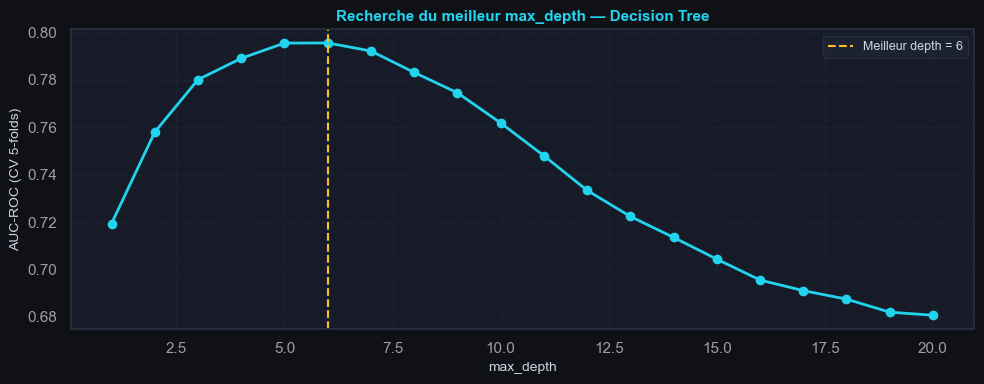

In [ ]:
# ── Recherche du meilleur max_depth ──────────────────────────────────────────
depth_scores = {}
for depth in range(1, 21):
    dt_tmp = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    auc_tmp = cross_val_score(dt_tmp, X_train, y_train, cv=cv_obj,
                              scoring='roc_auc', n_jobs=-1)
    depth_scores[depth] = auc_tmp.mean()

best_depth = max(depth_scores, key=depth_scores.get)
print(f"AUC-ROC CV par max_depth :")
for d, score in depth_scores.items():
    marker = " ← meilleur" if d == best_depth else ""
    print(f"  max_depth={d:>2}  →  AUC = {score:.4f}{marker}")

fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor(COLORS['bg'])
ax.set_facecolor(COLORS['bg2'])
ax.plot(list(depth_scores.keys()), list(depth_scores.values()),
        marker='o', color=COLORS['cyan'], linewidth=2, markersize=6)
ax.axvline(best_depth, color=COLORS['amber'], linestyle='--', linewidth=1.5,
           label=f'Meilleur depth = {best_depth}')
ax.set_xlabel("max_depth", fontsize=10, color=COLORS['text'])
ax.set_ylabel("AUC-ROC (CV 5-folds)", fontsize=10, color=COLORS['text'])
ax.set_title("Recherche du meilleur max_depth — Decision Tree",
             fontsize=11, fontweight='bold', color=COLORS['cyan'])
ax.legend(facecolor=COLORS['bg3'], edgecolor=COLORS['border'],
          labelcolor=COLORS['text'], fontsize=9)
ax.tick_params(colors=COLORS['muted'])
for spine in ax.spines.values(): spine.set_edgecolor(COLORS['border'])
plt.tight_layout()
plt.show()


In [ ]:
# ── Entraînement du Decision Tree avec le meilleur max_depth ─────────────────
model_dt = DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE)

auc  = cross_val_score(model_dt, X_train, y_train, cv=cv_obj, scoring='roc_auc',  n_jobs=-1)
f1   = cross_val_score(model_dt, X_train, y_train, cv=cv_obj, scoring='f1',        n_jobs=-1)
rec  = cross_val_score(model_dt, X_train, y_train, cv=cv_obj, scoring='recall',    n_jobs=-1)
prec = cross_val_score(model_dt, X_train, y_train, cv=cv_obj, scoring='precision', n_jobs=-1)
acc  = cross_val_score(model_dt, X_train, y_train, cv=cv_obj, scoring='accuracy',  n_jobs=-1)
gauc = 2 * auc - 1

results['Decision Tree'] = {
    'model': model_dt, 'uses_scale': False,
    'auc_mean': auc.mean(),  'auc_std':  auc.std(),
    'gauc_mean':gauc.mean(), 'gauc_std': gauc.std(),
    'f1_mean':  f1.mean(),   'f1_std':   f1.std(),
    'rec_mean': rec.mean(),  'rec_std':  rec.std(),
    'prec_mean':prec.mean(), 'prec_std': prec.std(),
    'acc_mean': acc.mean(),  'acc_std':  acc.std(),
}
print(f"  {'Decision Tree':<22} {auc.mean():.4f}   {gauc.mean():.4f}   "
      f"{f1.mean():.4f}   {rec.mean():.4f}   {prec.mean():.4f}   {acc.mean():.4f}")
print(f"  (max_depth optimal = {best_depth})")


  Decision Tree          0.7956   0.5912   0.7280   0.6937   0.7666   0.7391
  (max_depth optimal = 6)


## 3.6 Random Forest

La Forêt Aléatoire combine plusieurs arbres entraînés sur des sous-ensembles aléatoires
pour réduire l'overfitting et améliorer la généralisation.
Prédiction finale : vote majoritaire entre tous les arbres.

### Recherche des meilleurs hyperparamètres (RandomizedSearchCV)

`RandomizedSearchCV` est préféré à `GridSearchCV` ici car l'espace de paramètres est large,
il échantillonne `n_iter` combinaisons aléatoires plutôt que de les tester toutes.


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# ── Espace de recherche ───────────────────────────────────────────────────────
param_dist_rf = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [5, 8, 10, 12, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.5],
}

rf_base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

rf_search = RandomizedSearchCV(
    estimator   = rf_base,
    param_distributions = param_dist_rf,
    n_iter      = 30,             # 30 combinaisons testées
    cv          = cv_obj,         # même CV stratifiée 5-folds
    scoring     = 'roc_auc',      
    n_jobs      = -1,
    random_state= RANDOM_STATE,
    verbose     = 1,
    refit       = True            # réentraîne sur tout le train avec les meilleurs params
)

rf_search.fit(X_train, y_train)

print(f"\n✓ Meilleurs hyperparamètres Random Forest :")
for param, val in rf_search.best_params_.items():
    print(f"  {param:<22} : {val}")
print(f"\n  AUC-ROC CV (meilleure combinaison) : {rf_search.best_score_:.4f}")


Fitting 5 folds for each of 30 candidates, totalling 150 fits

✓ Meilleurs hyperparamètres Random Forest :
  n_estimators           : 300
  min_samples_split      : 10
  min_samples_leaf       : 1
  max_features           : 0.5
  max_depth              : 8

  AUC-ROC CV (meilleure combinaison) : 0.8130


In [ ]:
# ── Évaluation complète du Random Forest optimisé ────────────────────────────
model_rf = rf_search.best_estimator_   # déjà fitté sur tout X_train

auc  = cross_val_score(model_rf, X_train, y_train, cv=cv_obj, scoring='roc_auc',  n_jobs=-1)
f1   = cross_val_score(model_rf, X_train, y_train, cv=cv_obj, scoring='f1',        n_jobs=-1)
rec  = cross_val_score(model_rf, X_train, y_train, cv=cv_obj, scoring='recall',    n_jobs=-1)
prec = cross_val_score(model_rf, X_train, y_train, cv=cv_obj, scoring='precision', n_jobs=-1)
acc  = cross_val_score(model_rf, X_train, y_train, cv=cv_obj, scoring='accuracy',  n_jobs=-1)
gauc = 2 * auc - 1

results['Random Forest'] = {
    'model': model_rf, 'uses_scale': False,
    'best_params': rf_search.best_params_,
    'auc_mean': auc.mean(),  'auc_std':  auc.std(),
    'gauc_mean':gauc.mean(), 'gauc_std': gauc.std(),
    'f1_mean':  f1.mean(),   'f1_std':   f1.std(),
    'rec_mean': rec.mean(),  'rec_std':  rec.std(),
    'prec_mean':prec.mean(), 'prec_std': prec.std(),
    'acc_mean': acc.mean(),  'acc_std':  acc.std(),
}
print(f"  {'Random Forest':<22} {auc.mean():.4f}   {gauc.mean():.4f}   "
      f"{f1.mean():.4f}   {rec.mean():.4f}   {prec.mean():.4f}   {acc.mean():.4f}")
print(f"  (hyperparamètres optimisés via RandomizedSearchCV — 30 itérations)")


  Random Forest          0.8130   0.6259   0.7306   0.6814   0.7875   0.7469
  (hyperparamètres optimisés via RandomizedSearchCV — 30 itérations)


## 3.7 KNN (k=7)


In [ ]:
model_knn = KNeighborsClassifier(n_neighbors=7, metric='euclidean', weights='distance')

auc  = cross_val_score(model_knn, X_scaled, y_train, cv=cv_obj, scoring='roc_auc',  n_jobs=-1)
f1   = cross_val_score(model_knn, X_scaled, y_train, cv=cv_obj, scoring='f1',        n_jobs=-1)
rec  = cross_val_score(model_knn, X_scaled, y_train, cv=cv_obj, scoring='recall',    n_jobs=-1)
prec = cross_val_score(model_knn, X_scaled, y_train, cv=cv_obj, scoring='precision', n_jobs=-1)
acc  = cross_val_score(model_knn, X_scaled, y_train, cv=cv_obj, scoring='accuracy',  n_jobs=-1)
gauc = 2 * auc - 1

results['KNN (k=7)'] = {
    'model': model_knn, 'uses_scale': True,
    'auc_mean': auc.mean(),  'auc_std':  auc.std(),
    'gauc_mean':gauc.mean(), 'gauc_std': gauc.std(),
    'f1_mean':  f1.mean(),   'f1_std':   f1.std(),
    'rec_mean': rec.mean(),  'rec_std':  rec.std(),
    'prec_mean':prec.mean(), 'prec_std': prec.std(),
    'acc_mean': acc.mean(),  'acc_std':  acc.std(),
}
print(f"  {'KNN (k=7)':<22} {auc.mean():.4f}   {gauc.mean():.4f}   "
      f"{f1.mean():.4f}   {rec.mean():.4f}   {prec.mean():.4f}   {acc.mean():.4f}")


  KNN (k=7)              0.7619   0.5238   0.6848   0.6530   0.7199   0.6972


## 3.8 Récapitulatif 

In [ ]:
best_name = max(results, key=lambda k: results[k]['auc_mean'])
best_cfg  = results[best_name]

header = (f"{'Modèle':<22} {'AUC-ROC':>8} {'gAUC':>8} "
          f"{'F1':>8} {'Recall':>8} {'Prec.':>8} {'Acc.':>8}")
print(f"Cross-validation {CV_FOLDS}-folds stratifiée — {len(FEATURE_COLS_DEFINITIVES)} features\n")
print(header)
print("-" * 76)
for name, res in results.items():
    print(f"  {name:<22} "
          f"{res['auc_mean']:.4f}   {res['gauc_mean']:.4f}   "
          f"{res['f1_mean']:.4f}   {res['rec_mean']:.4f}   "
          f"{res['prec_mean']:.4f}   {res['acc_mean']:.4f}")

print(f"\n✓ Meilleur modèle (AUC-ROC) : {best_name}")
for m, k in [('AUC-ROC','auc'),('Gini','gauc'),('F1','f1'),
             ('Recall','rec'),('Precision','prec'),('Accuracy','acc')]:
    print(f"  {m:<12}: {best_cfg[k+'_mean']:.4f} ± {best_cfg[k+'_std']:.4f}")


Cross-validation 5-folds stratifiée — 20 features

Modèle                  AUC-ROC     gAUC       F1   Recall    Prec.     Acc.
----------------------------------------------------------------------------
  Logistic Regression    0.7695   0.5391   0.6884   0.6195   0.7746   0.7175
  Decision Tree          0.7956   0.5912   0.7280   0.6937   0.7666   0.7391
  Random Forest          0.8130   0.6259   0.7306   0.6814   0.7875   0.7469
  KNN (k=7)              0.7619   0.5238   0.6848   0.6530   0.7199   0.6972

✓ Meilleur modèle (AUC-ROC) : Random Forest
  AUC-ROC     : 0.8130 ± 0.0062
  Gini        : 0.6259 ± 0.0124
  F1          : 0.7306 ± 0.0066
  Recall      : 0.6814 ± 0.0085
  Precision   : 0.7875 ± 0.0066
  Accuracy    : 0.7469 ± 0.0056


In [ ]:
# ── Tableau récapitulatif stylisé ─────────────────────────────────────────────
rows = []
for name, res in results.items():
    rows.append({
        'Modèle':    name,
        'AUC-ROC':   f"{res['auc_mean']:.4f} ± {res['auc_std']:.4f}",
        'Gini':      f"{res['gauc_mean']:.4f} ± {res['gauc_std']:.4f}",
        'F1-Score':  f"{res['f1_mean']:.4f} ± {res['f1_std']:.4f}",
        'Recall':    f"{res['rec_mean']:.4f} ± {res['rec_std']:.4f}",
        'Precision': f"{res['prec_mean']:.4f} ± {res['prec_std']:.4f}",
        'Accuracy':  f"{res['acc_mean']:.4f} ± {res['acc_std']:.4f}",
    })

df_bench = pd.DataFrame(rows).set_index('Modèle')

def highlight_best(col):
    vals = col.str.split(' ').str[0].astype(float)
    return ['background-color:#0d2a0d;color:#7fff7f;font-weight:bold'
            if v == vals.max() else '' for v in vals]

display(df_bench.style
        .apply(highlight_best, axis=0)
        .set_caption(f"✓ Meilleur modèle sélectionné : {best_name} (critère AUC-ROC)"))


,AUC-ROC,Gini,F1-Score,Recall,Precision,Accuracy
Modèle,,,,,,
Logistic Regression,0.7695 ± 0.0120,0.5391 ± 0.0240,0.6884 ± 0.0093,0.6195 ± 0.0064,0.7746 ± 0.0156,0.7175 ± 0.0097
Decision Tree,0.7956 ± 0.0105,0.5912 ± 0.0209,0.7280 ± 0.0144,0.6937 ± 0.0249,0.7666 ± 0.0168,0.7391 ± 0.0120
Random Forest,0.8130 ± 0.0062,0.6259 ± 0.0124,0.7306 ± 0.0066,0.6814 ± 0.0085,0.7875 ± 0.0066,0.7469 ± 0.0056
KNN (k=7),0.7619 ± 0.0060,0.5238 ± 0.0121,0.6848 ± 0.0142,0.6530 ± 0.0162,0.7199 ± 0.0160,0.6972 ± 0.0135


## 3.9 Entraînement final & Prédictions sur le test Kaggle

Le meilleur modèle est entraîné sur **tout `train_data`**, puis appliqué directement au jeu test pour générer les prédictions finales.


In [ ]:
# ── Entraînement final sur tout le train ─────────────────────────────────────
best_model = best_cfg['model']
X_fit  = X_scaled if best_cfg['uses_scale'] else X_train
X_pred = X_test_sc if best_cfg['uses_scale'] else X_test

best_model.fit(X_fit, y_train)

# ── Prédictions sur le test ────────────────────────────────────────────
te_pred  = best_model.predict(X_pred)
te_proba = best_model.predict_proba(X_pred)[:, 1]

test_data['Pred_Transported']       = te_pred
test_data['Pred_Proba_Transport']   = te_proba.round(4)
test_data['Pred_Proba_NoTransport'] = (1 - te_proba).round(4)

print(f"✓ {best_name} entraîné sur {len(X_fit):,} exemples ({len(FEATURE_COLS_DEFINITIVES)} features)")
print(f"  Prédictions test : {te_pred.sum():,} transportés / {len(te_pred)-te_pred.sum():,} non-transportés")
print(f"  Probabilité moyenne de transport : {te_proba.mean():.4f}")


✓ Random Forest entraîné sur 8,693 exemples (20 features)
  Prédictions test : 1,847 transportés / 2,430 non-transportés
  Probabilité moyenne de transport : 0.5184


In [ ]:
# ── Métriques sur le train complet (indicatives — pas de holdout) ────────────
# Ces métriques reflètent la capacité du modèle à mémoriser le train. Les métriques fiables sont celles de la cross-validation section 3.8.

tr_pred  = best_model.predict(X_fit)
tr_proba = best_model.predict_proba(X_fit)[:, 1]

print(f"Métriques sur train complet (indicatives — se reporter à la CV pour évaluation réelle) :\n")
for m_name, func, kwargs in [
    ('AUC-ROC',   roc_auc_score,   {'y_score': tr_proba}),
    ('Gini',      lambda a, **k: 2 * roc_auc_score(a, **k) - 1, {'y_score': tr_proba}),
    ('F1-Score',  f1_score,        {}),
    ('Recall',    recall_score,    {}),
    ('Precision', precision_score, {}),
    ('Accuracy',  accuracy_score,  {}),
]:
    val = func(y_train, **kwargs) if 'y_score' in kwargs else func(y_train, tr_pred, **kwargs)
    print(f"  {m_name:<12}: {val:.4f}")

print()
print("Les métriques train peuvent être gonflées par overfitting.")
print(f"    Métriques CV (fiables) : AUC={best_cfg['auc_mean']:.4f} | "
      f"F1={best_cfg['f1_mean']:.4f} | Acc={best_cfg['acc_mean']:.4f}")

Métriques sur train complet (indicatives — se reporter à la CV pour évaluation réelle) :

  AUC-ROC     : 0.8729
  Gini        : 0.7458
  F1-Score    : 0.7735
  Recall      : 0.7193
  Precision   : 0.8366
  Accuracy    : 0.7879

Les métriques train peuvent être gonflées par overfitting.
    Métriques CV (fiables) : AUC=0.8130 | F1=0.7306 | Acc=0.7469


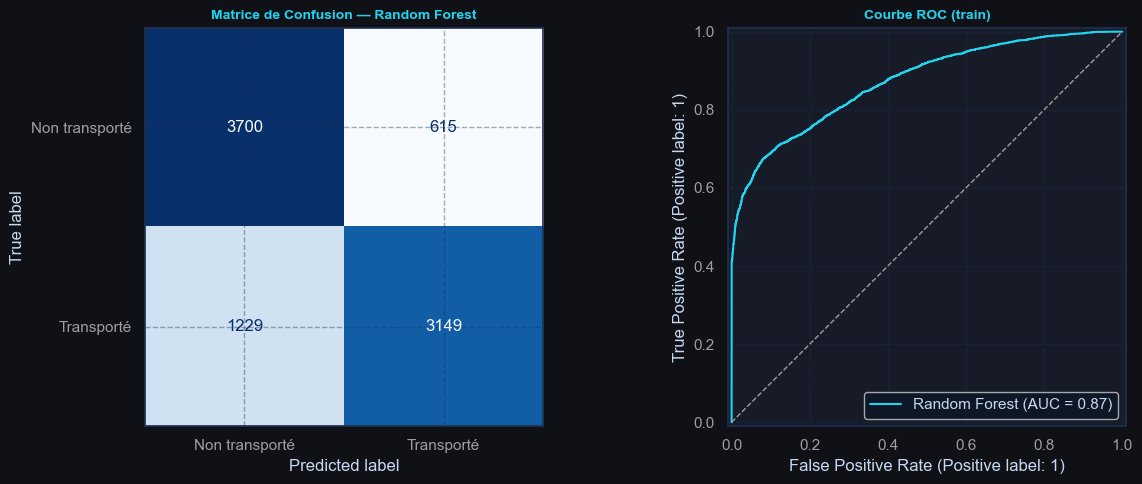

                precision    recall  f1-score   support

Non transporté       0.75      0.86      0.80      4315
    Transporté       0.84      0.72      0.77      4378

      accuracy                           0.79      8693
     macro avg       0.79      0.79      0.79      8693
  weighted avg       0.79      0.79      0.79      8693



In [ ]:
# ── Matrice de confusion + Courbe ROC (train) ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor(COLORS['bg'])

cm = confusion_matrix(y_train, tr_pred)
ConfusionMatrixDisplay(cm, display_labels=['Non transporté', 'Transporté']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Matrice de Confusion — {best_name}',
                  fontsize=10, fontweight='bold', color=COLORS['cyan'])
axes[0].set_facecolor(COLORS['bg2'])

RocCurveDisplay.from_estimator(best_model, X_fit, y_train,
    ax=axes[1], color=COLORS['cyan'], name=best_name)
axes[1].plot([0, 1], [0, 1], linestyle='--', color=COLORS['muted'], linewidth=1)
axes[1].set_title('Courbe ROC (train)', fontsize=10, fontweight='bold', color=COLORS['cyan'])
axes[1].set_facecolor(COLORS['bg2'])
plt.tight_layout()
plt.show()

print(classification_report(y_train, tr_pred,
      target_names=['Non transporté', 'Transporté']))


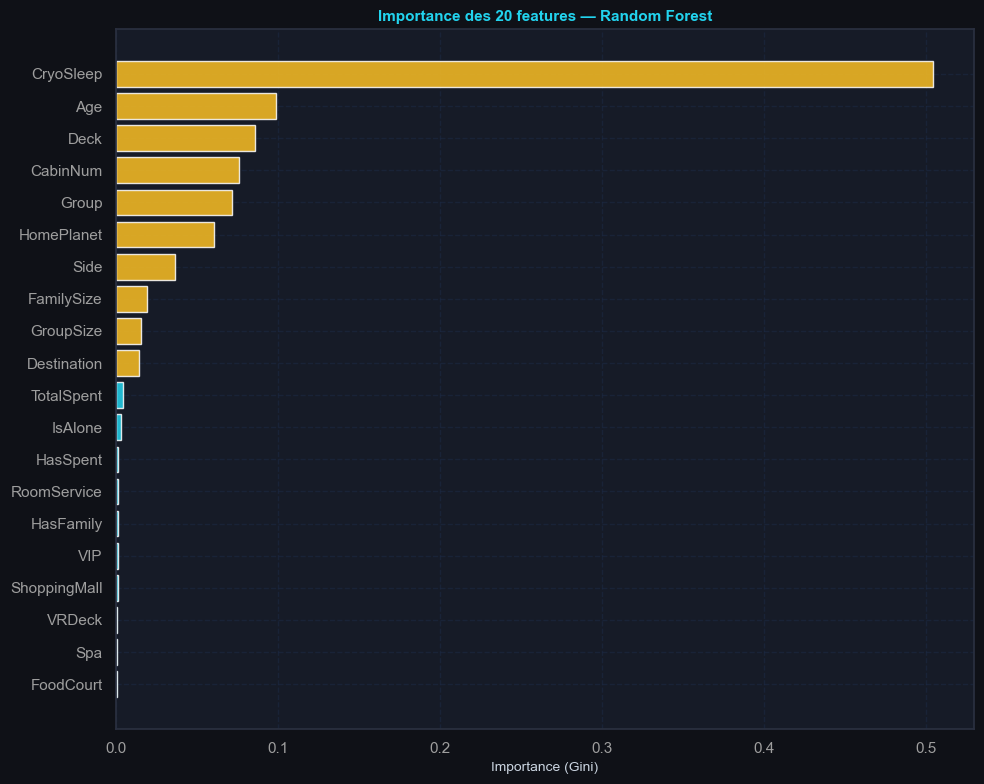

Top 5 features :
  CryoSleep              0.5043
  Age                    0.0990
  Deck                   0.0858
  CabinNum               0.0760
  Group                  0.0718


In [ ]:
# ── Importance des features ────────────────────────────────────────────────────
if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_,
                    index=FEATURE_COLS_DEFINITIVES).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 8))
    fig.patch.set_facecolor(COLORS['bg'])
    ax.set_facecolor(COLORS['bg2'])

    colors_imp = [COLORS['amber'] if v > imp.median() else COLORS['cyan']
                  for v in imp.values]
    ax.barh(imp.index, imp.values, color=colors_imp, alpha=0.85)
    ax.set_title(f'Importance des {len(FEATURE_COLS_DEFINITIVES)} features — {best_name}',
                 fontsize=11, fontweight='bold', color=COLORS['cyan'])
    ax.set_xlabel('Importance (Gini)', fontsize=10, color=COLORS['text'])
    ax.tick_params(colors=COLORS['muted'])
    for spine in ax.spines.values(): spine.set_edgecolor(COLORS['border'])

    plt.tight_layout()
    plt.show()

    print("Top 5 features :")
    for feat, val in imp.sort_values(ascending=False).head(5).items():
        print(f"  {feat:<22} {val:.4f}")

elif hasattr(best_model, 'coef_'):
    coef = pd.Series(np.abs(best_model.coef_[0]),
                     index=FEATURE_COLS_DEFINITIVES).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(10, 8))
    fig.patch.set_facecolor(COLORS['bg'])
    ax.set_facecolor(COLORS['bg2'])
    ax.barh(coef.index, coef.values, color=COLORS['purple'], alpha=0.8)
    ax.set_title(f'Coefficients absolus — {best_name}',
                 fontsize=11, fontweight='bold', color=COLORS['cyan'])
    ax.set_xlabel('|Coefficient|', fontsize=10, color=COLORS['text'])
    ax.tick_params(colors=COLORS['muted'])
    for spine in ax.spines.values(): spine.set_edgecolor(COLORS['border'])
    plt.tight_layout()
    plt.show()


## 3.10 Export : Fichier de soumission Kaggle


In [ ]:
# Récupérer les PassengerIds originaux du test
test_original = pd.read_csv('Données/test.csv')

submission = pd.DataFrame({
    'PassengerId': test_original['PassengerId'],
    'Transported': te_pred.astype(bool)
})

submission.to_csv('submission.csv', index=False)

print(f"✓ submission.csv exporté — {len(submission):,} lignes")
print(f"  True  (transporté)     : {submission['Transported'].sum():,}")
print(f"  False (non transporté) : {(~submission['Transported']).sum():,}")
print()
display(submission.head(10))


✓ submission.csv exporté — 4,277 lignes
  True  (transporté)     : 1,847
  False (non transporté) : 2,430



,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,False
4,0023_01,False
5,0027_01,False
6,0029_01,True
7,0032_01,True
8,0032_02,True
9,0033_01,False


---
# 4. ACM — Analyse des Correspondances Multiples

L'ACM est l'équivalent de l'ACP pour les variables **catégorielles**.  
Elle réduit la dimensionnalité en créant des axes factoriels qui capturent les associations entre modalités.

**Implémentation :** classe `MCA` native NumPy.
**Variables retenues :** celles avec V de Cramér > 0 vis-à-vis de `Transported`.

> L'ACM est **ajustée sur le train uniquement** puis appliquée (transform) au test — pas de data leakage.


## 4.1 Classe MCA native 


In [ ]:
# ── Classe MCA native NumPy/sklearn — remplace prince.MCA ────────────────────
# Interface identique : .fit() / .transform() / .column_coordinates() / .eigenvalues_

class MCA:
    """
    Multiple Correspondence Analysis — implémentation native NumPy/sklearn.
    Aucune dépendance externe requise.
    """
    def __init__(self, n_components=10, random_state=42):
        self.n_components = n_components
        self.random_state = random_state
        self.enc_          = None
        self.eigenvalues_  = None
        self.col_names_    = None
        self._Vt = self._sv = self._Dc_sqrt_inv = self._c = None

    def fit(self, X):
        X = pd.DataFrame(X).astype(str)
        self.enc_ = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        Z = self.enc_.fit_transform(X)
        self.col_names_ = self.enc_.get_feature_names_out(list(X.columns))

        n = Z.sum()
        S = Z / n
        r = S.sum(axis=1, keepdims=True)
        c = S.sum(axis=0, keepdims=True)
        self._c = c

        Dr_sqrt_inv = np.diag(1.0 / np.sqrt(S.sum(axis=1) + 1e-12))
        self._Dc_sqrt_inv = np.diag(1.0 / np.sqrt(S.sum(axis=0) + 1e-12))

        S_tilde = Dr_sqrt_inv @ (S - r @ c) @ self._Dc_sqrt_inv
        U, sv, Vt = np.linalg.svd(S_tilde, full_matrices=False)

        k = min(self.n_components, len(sv) - 1)
        self.eigenvalues_ = sv[1:k+1] ** 2
        self._sv  = sv[1:k+1]
        self._Vt  = Vt[1:k+1, :]
        return self

    def transform(self, X):
        X  = pd.DataFrame(X).astype(str)
        Z  = self.enc_.transform(X)
        n  = Z.sum()
        S  = Z / n
        r  = S.sum(axis=1, keepdims=True)
        Dr_sqrt_inv = np.diag(1.0 / np.sqrt(S.sum(axis=1) + 1e-12))
        S_tilde = Dr_sqrt_inv @ (S - r @ self._c) @ self._Dc_sqrt_inv
        coords  = S_tilde @ self._Vt.T / (self._sv + 1e-12)
        return pd.DataFrame(
            coords,
            index=X.index,
            columns=[f'ACM_Axe{i+1}' for i in range(coords.shape[1])]
        )

    def column_coordinates(self, X):
        col_c = self._Dc_sqrt_inv @ self._Vt.T / (self._sv + 1e-12)
        return pd.DataFrame(
            col_c,
            index=self.col_names_,
            columns=[f'ACM_Axe{i+1}' for i in range(col_c.shape[1])]
        )

N_ACM_COMPS = 10
print("✓ Classe MCA chargée")


✓ Classe MCA chargée


## 4.2 Ajustement & Projection


In [ ]:
# Variables catégorielles pour l'ACM
# On reprend train_data et test_data AVANT le drop PassengerId/Name

acm_cat_cols = ['HomePlanet', 'Destination', 'Deck', 'Side',
                'CryoSleep', 'VIP', 'IsAlone', 'HasSpent', 'HasFamily']

# Reconstruire les DataFrames catégoriels depuis train_data / test_data
# (qui existent encore à ce stade — PassengerId et Name ont été droppés mais
#  les colonnes catégorielles sont toujours présentes)

train_acm_df = train_data[acm_cat_cols].astype(str)
test_acm_df  = test_data[acm_cat_cols].astype(str)

# Ajustement sur le TRAIN uniquement
acm = MCA(n_components=N_ACM_COMPS)
acm.fit(train_acm_df)

# Projection
train_coords = acm.transform(train_acm_df)
test_coords  = acm.transform(test_acm_df)

acm_col_names = [f'ACM_Axe{i+1}' for i in range(N_ACM_COMPS)]

# Variance expliquée
eig_vals      = acm.eigenvalues_
explained_var = eig_vals / eig_vals.sum() * 100
cumulative_var = np.cumsum(explained_var)

# Tableau récapitulatif
eig_df = pd.DataFrame({
    'Axe':                    [f'Axe {i+1}' for i in range(N_ACM_COMPS)],
    'Valeur propre':           eig_vals.round(4),
    'Variance expliquée (%)':  explained_var.round(2),
    'Variance cumulée (%)':    cumulative_var.round(2)
})

print(f"✓ ACM ajustée sur {len(train_acm_df):,} individus | {N_ACM_COMPS} composantes")
print(f"  Variables : {acm_cat_cols}")
print()
display(eig_df.style
        .bar(subset=['Variance expliquée (%)'], color='#00d4ff')
        .format({'Valeur propre': '{:.4f}',
                 'Variance expliquée (%)': '{:.2f}%',
                 'Variance cumulée (%)': '{:.2f}%'})
        .set_caption("Variance expliquée par axe ACM"))


✓ ACM ajustée sur 8,693 individus | 10 composantes
  Variables : ['HomePlanet', 'Destination', 'Deck', 'Side', 'CryoSleep', 'VIP', 'IsAlone', 'HasSpent', 'HasFamily']



,Axe,Valeur propre,Variance expliquée (%),Variance cumulée (%)
0,Axe 1,0.1854,15.20%,15.20%
1,Axe 2,0.1326,10.87%,26.07%
2,Axe 3,0.1245,10.21%,36.28%
3,Axe 4,0.1203,9.86%,46.14%
4,Axe 5,0.1140,9.35%,55.49%
5,Axe 6,0.1129,9.26%,64.75%
6,Axe 7,0.1112,9.12%,73.86%
7,Axe 8,0.1090,8.94%,82.80%
8,Axe 9,0.1085,8.90%,91.70%
9,Axe 10,0.1012,8.30%,100.00%


## 4.3 Scree Plot & Projection individus


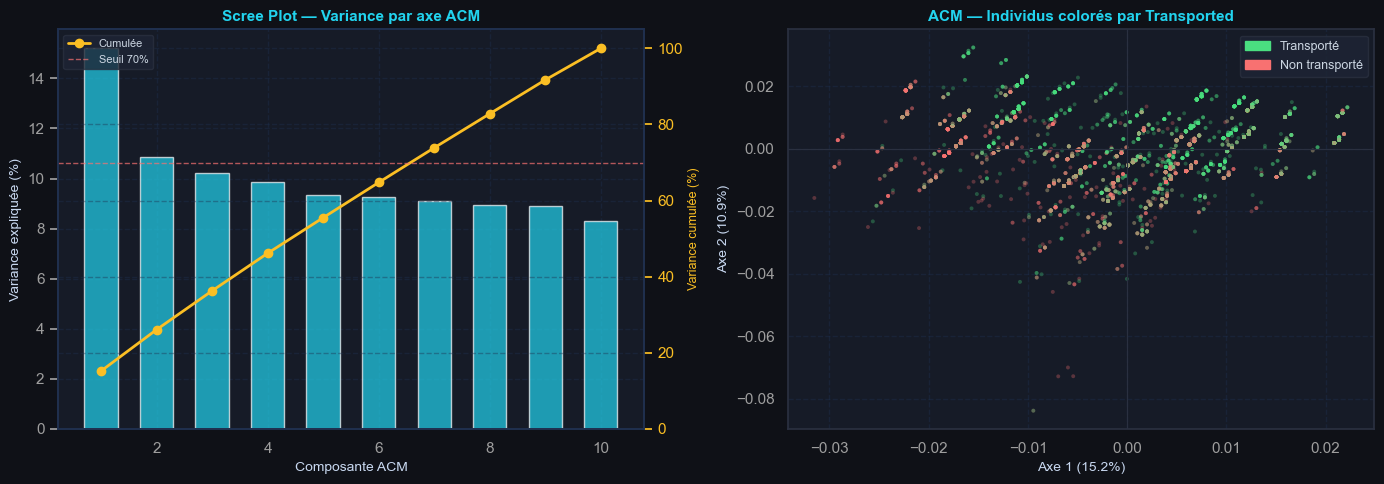

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(COLORS['bg'])

# Scree plot
x_pos = np.arange(1, N_ACM_COMPS + 1)
axes[0].bar(x_pos, explained_var, color=COLORS['cyan'], alpha=0.7, width=0.6)
ax_r = axes[0].twinx()
ax_r.plot(x_pos, cumulative_var, color=COLORS['amber'], marker='o',
          markersize=6, linewidth=2, label='Cumulée')
ax_r.axhline(70, color=COLORS['red'], linestyle='--', linewidth=1,
             alpha=0.7, label='Seuil 70%')
ax_r.set_ylim(0, 105)
ax_r.tick_params(colors=COLORS['amber'])
ax_r.set_ylabel('Variance cumulée (%)', color=COLORS['amber'], fontsize=9)
ax_r.legend(facecolor=COLORS['bg3'], edgecolor=COLORS['border'],
            labelcolor=COLORS['text'], fontsize=8)
axes[0].set_xlabel('Composante ACM', fontsize=10)
axes[0].set_ylabel('Variance expliquée (%)', fontsize=10)
axes[0].set_title('Scree Plot — Variance par axe ACM',
                  fontsize=11, fontweight='bold', color=COLORS['cyan'])
axes[0].set_facecolor(COLORS['bg2'])
for spine in axes[0].spines.values(): spine.set_edgecolor(COLORS['border'])

# Projection individus colorée par Transported
tc   = train_data['Transported'].values
pt_c = [COLORS['green'] if t == 1 else COLORS['red'] for t in tc]
axes[1].scatter(train_coords['ACM_Axe1'], train_coords['ACM_Axe2'],
                c=pt_c, alpha=0.3, s=8, linewidths=0)
axes[1].axhline(0, color=COLORS['border'], linewidth=0.8)
axes[1].axvline(0, color=COLORS['border'], linewidth=0.8)
axes[1].set_xlabel(f'Axe 1 ({explained_var[0]:.1f}%)', fontsize=10)
axes[1].set_ylabel(f'Axe 2 ({explained_var[1]:.1f}%)', fontsize=10)
axes[1].set_title('ACM — Individus colorés par Transported',
                  fontsize=11, fontweight='bold', color=COLORS['cyan'])
axes[1].set_facecolor(COLORS['bg2'])
for spine in axes[1].spines.values(): spine.set_edgecolor(COLORS['border'])

patches = [mpatches.Patch(color=COLORS['green'], label='Transporté'),
           mpatches.Patch(color=COLORS['red'],   label='Non transporté')]
axes[1].legend(handles=patches, facecolor=COLORS['bg3'],
               edgecolor=COLORS['border'], labelcolor=COLORS['text'], fontsize=9)

plt.tight_layout()
plt.show()


## 4.4 Contributions des modalités aux axes


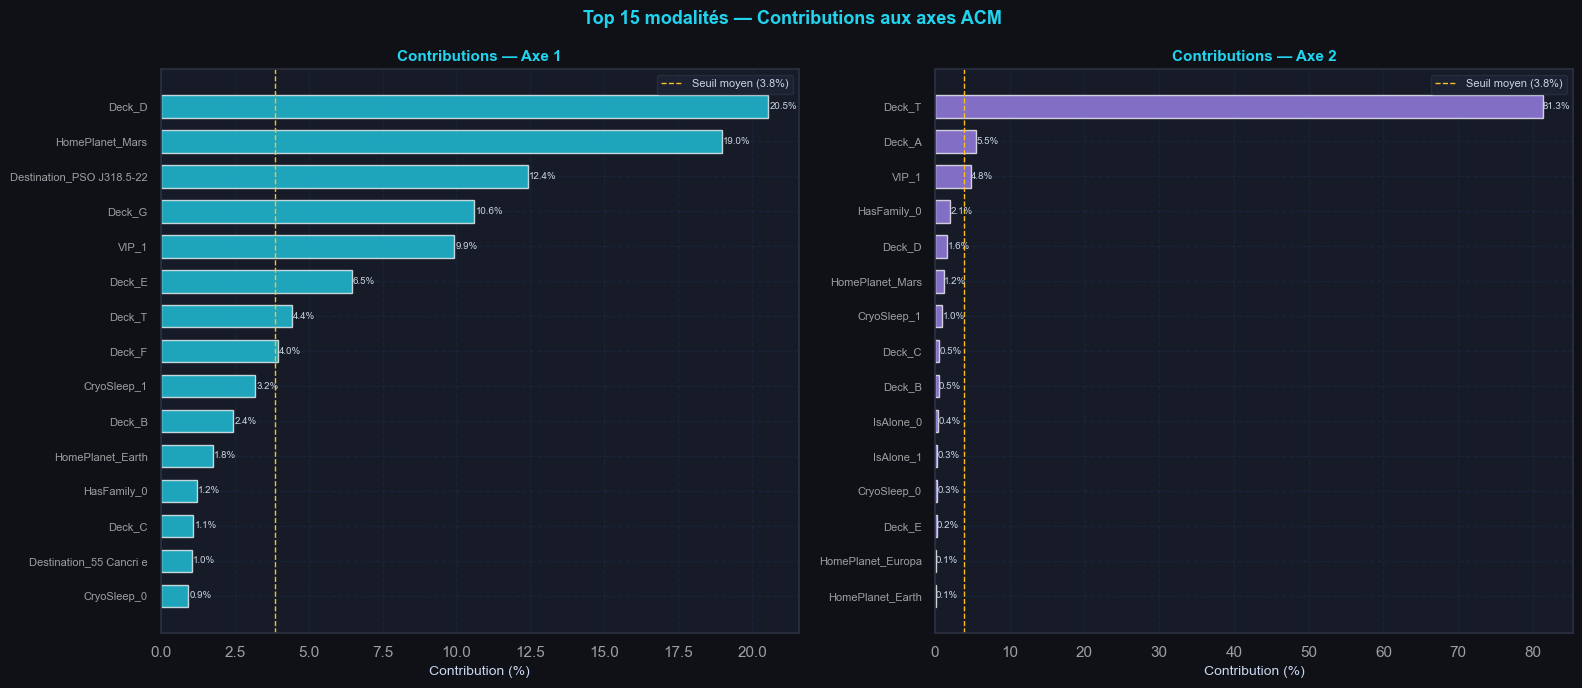

Top 5 contributeurs Axe 1 :
Deck_D                       20.55
HomePlanet_Mars              18.97
Destination_PSO J318.5-22    12.40
Deck_G                       10.60
VIP_1                         9.91

Top 5 contributeurs Axe 2 :
Deck_T         81.28
Deck_A          5.47
VIP_1           4.77
HasFamily_0     2.07
Deck_D          1.64


In [ ]:
col_coords = acm.column_coordinates(train_acm_df)

def compute_contributions(col_coords_df, axis_idx):
    sq = col_coords_df.iloc[:, axis_idx] ** 2
    return (sq / sq.sum() * 100).sort_values(ascending=False)

contrib_ax1 = compute_contributions(col_coords, 0)
contrib_ax2 = compute_contributions(col_coords, 1)
top_n = 15

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(COLORS['bg'])

for ax, contrib, title, color in zip(
    axes,
    [contrib_ax1.head(top_n), contrib_ax2.head(top_n)],
    ['Contributions — Axe 1', 'Contributions — Axe 2'],
    [COLORS['cyan'], COLORS['purple']]
):
    sc = contrib.sort_values()
    mean_thresh = 100 / len(contrib_ax1)
    ax.barh(range(len(sc)), sc.values, color=color, alpha=0.75, height=0.65)
    ax.set_yticks(range(len(sc)))
    ax.set_yticklabels(sc.index, fontsize=8)
    ax.axvline(mean_thresh, color=COLORS['amber'], linestyle='--', linewidth=1,
               label=f'Seuil moyen ({mean_thresh:.1f}%)')
    ax.set_xlabel('Contribution (%)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold', color=COLORS['cyan'])
    ax.set_facecolor(COLORS['bg2'])
    ax.legend(facecolor=COLORS['bg3'], edgecolor=COLORS['border'],
              labelcolor=COLORS['text'], fontsize=8)
    for bar, val in zip(ax.patches, sc.values):
        ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', ha='left',
                color=COLORS['text'], fontsize=7)
    for spine in ax.spines.values(): spine.set_edgecolor(COLORS['border'])

fig.suptitle('Top 15 modalités — Contributions aux axes ACM',
             fontsize=13, fontweight='bold', color=COLORS['cyan'])
plt.tight_layout()
plt.show()

print("Top 5 contributeurs Axe 1 :")
print(contrib_ax1.head(5).round(2).to_string())
print("\nTop 5 contributeurs Axe 2 :")
print(contrib_ax2.head(5).round(2).to_string())


---
# 5. Clustering K-Means sur les Axes ACM

On applique un K-Means sur les coordonnées ACM pour segmenter les passagers en groupes homogènes.

**Principe :** les axes ACM capturent les associations entre variables catégorielles.  
Clustériser dans cet espace regroupe les passagers avec des **profils catégoriels similaires**.

**Nombre d'axes retenus :** axes dont la variance cumulée atteint 70% (ou minimum 2).


## 5.1 Choix du nombre d'axes & méthode du coude


Axes retenus (var ≥ 70%) : 7 axe(s)
  → Variance cumulée : 73.9%


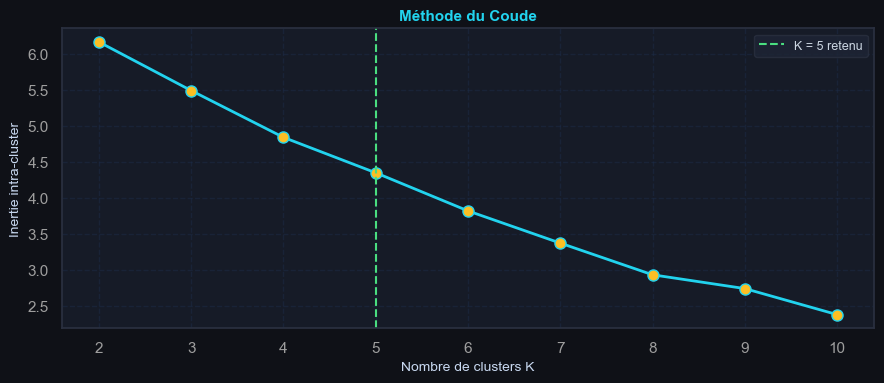

In [ ]:
N_CLUSTERS = 5

# Axes retenus pour le clustering (variance cumulée ≥ 70%)
n_axes_kept = max(2, int(np.argmax(cumulative_var >= 70.0)) + 1)
print(f"Axes retenus (var ≥ 70%) : {n_axes_kept} axe(s)")
print(f"  → Variance cumulée : {cumulative_var[n_axes_kept-1]:.1f}%")
if n_axes_kept == 2:
    print(f"  (seuil 70% non atteint sur {N_ACM_COMPS} axes — 2 axes minimum retenus)")

kept_cols = [f'ACM_Axe{i+1}' for i in range(n_axes_kept)]
tr_km = train_coords[kept_cols].values
te_km = test_coords[kept_cols].values

# Méthode du coude
inertias = []
for k in range(2, 11):
    km_tmp = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km_tmp.fit(tr_km)
    inertias.append(km_tmp.inertia_)

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor(COLORS['bg'])
ax.set_facecolor(COLORS['bg2'])
ax.plot(range(2, 11), inertias, marker='o', color=COLORS['cyan'],
        linewidth=2, markersize=8, markerfacecolor=COLORS['amber'])
ax.axvline(N_CLUSTERS, color=COLORS['green'], linestyle='--', linewidth=1.5,
           label=f'K = {N_CLUSTERS} retenu')
ax.set_xlabel('Nombre de clusters K', fontsize=10)
ax.set_ylabel('Inertie intra-cluster', fontsize=10)
ax.set_title('Méthode du Coude', fontsize=11, fontweight='bold', color=COLORS['cyan'])
ax.legend(facecolor=COLORS['bg3'], edgecolor=COLORS['border'],
          labelcolor=COLORS['text'], fontsize=9)
ax.grid(True)
for spine in ax.spines.values(): spine.set_edgecolor(COLORS['border'])
plt.tight_layout()
plt.show()


## 5.2 Entraînement K-Means & nommage des clusters


In [ ]:
# Entraînement K-Means
kmeans_model = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=20)
kmeans_model.fit(tr_km)

tr_cl = kmeans_model.labels_
te_cl = kmeans_model.predict(te_km)

# Statistiques par cluster
cluster_stats = {}
for cid in range(N_CLUSTERS):
    mask = tr_cl == cid
    members = train_data[mask]
    cluster_stats[cid] = {
        'n':        mask.sum(),
        'rate':     round(float(members['Transported'].mean()), 4),
        'cryo':     round(float(members['CryoSleep'].mean()), 4),
        'avg_age':  round(float(members['Age'].mean()), 1),
        'avg_spend':round(float(members['TotalSpent'].mean()), 1),
    }

# Nommage : tri par taux de transport décroissant
sorted_clusters = sorted(cluster_stats.items(), key=lambda x: -x[1]['rate'])
cluster_name_pool = ['Voyageurs Pro', 'Luxuria', 'Cryo Corps', 'Jeunes Nomades', 'Colons']
cluster_names_map = {cid: cluster_name_pool[rank]
                     for rank, (cid, _) in enumerate(sorted_clusters)}

# Ajout aux DataFrames
train_data['ClusterID']   = tr_cl
test_data['ClusterID']    = te_cl
train_data['ClusterName'] = train_data['ClusterID'].map(cluster_names_map)
test_data['ClusterName']  = test_data['ClusterID'].map(cluster_names_map)

for cid in range(N_CLUSTERS):
    cluster_stats[cid]['name'] = cluster_names_map[cid]

print(f"{'Cluster':<4} {'Nom':<20} {'N':>6}  {'Transport':>10}  {'CryoSleep':>10}  {'Âge moy':>8}  {'Dép. moy':>9}")
print("-" * 75)
for cid in range(N_CLUSTERS):
    s = cluster_stats[cid]
    print(f"  {cid}   {s['name']:<20} {s['n']:>6}  "
          f"{s['rate']:>9.1%}  {s['cryo']:>9.1%}  "
          f"{s['avg_age']:>8.1f}  {s['avg_spend']:>9.1f}")


Cluster Nom                       N   Transport   CryoSleep   Âge moy   Dép. moy
---------------------------------------------------------------------------
  0   Colons                  788      34.4%      17.4%      29.4        6.1
  1   Cryo Corps              566      55.8%      35.9%      31.4       10.9
  2   Jeunes Nomades         3261      38.7%       9.8%      30.1       12.8
  3   Luxuria                1500      58.0%      39.5%      28.9       10.8
  4   Voyageurs Pro          2578      64.4%      69.3%      24.7        7.7


## 5.3 Visualisation des clusters


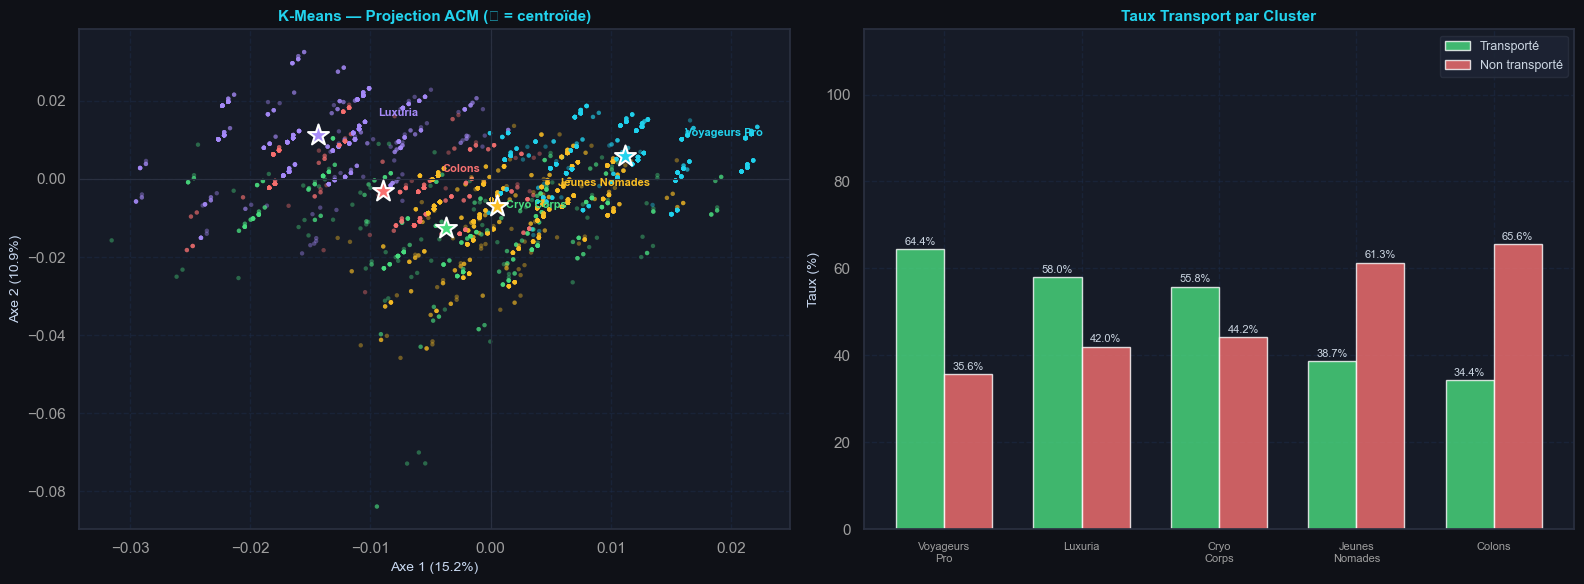

In [ ]:
cluster_colors_map = {
    'Voyageurs Pro':  COLORS['cyan'],
    'Luxuria':        COLORS['purple'],
    'Cryo Corps':     COLORS['green'],
    'Jeunes Nomades': COLORS['amber'],
    'Colons':         COLORS['red'],
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(COLORS['bg'])

# Projection scatter colorée par cluster
pt_colors = [cluster_colors_map[cluster_names_map[c]] for c in tr_cl]
axes[0].scatter(train_coords['ACM_Axe1'], train_coords['ACM_Axe2'],
                c=pt_colors, alpha=0.4, s=10, linewidths=0)

# Centroïdes
centers2 = kmeans_model.cluster_centers_[:, :2]
for cid in range(N_CLUSTERS):
    cx, cy = centers2[cid]
    col = cluster_colors_map[cluster_names_map[cid]]
    axes[0].scatter(cx, cy, s=250, c=col, edgecolors='white',
                    linewidths=1.5, zorder=5, marker='*')
    axes[0].annotate(cluster_names_map[cid], xy=(cx, cy),
                     xytext=(cx + 0.005, cy + 0.005), fontsize=8,
                     color=col, fontweight='bold')

axes[0].axhline(0, color=COLORS['border'], linewidth=0.8)
axes[0].axvline(0, color=COLORS['border'], linewidth=0.8)
axes[0].set_xlabel(f'Axe 1 ({explained_var[0]:.1f}%)', fontsize=10)
axes[0].set_ylabel(f'Axe 2 ({explained_var[1]:.1f}%)', fontsize=10)
axes[0].set_title('K-Means — Projection ACM (★ = centroïde)',
                  fontsize=11, fontweight='bold', color=COLORS['cyan'])
axes[0].set_facecolor(COLORS['bg2'])
for spine in axes[0].spines.values(): spine.set_edgecolor(COLORS['border'])

# Barres taux transport / non-transport par cluster
x = np.arange(N_CLUSTERS)
w = 0.35
ordered = sorted(range(N_CLUSTERS), key=lambda c: -cluster_stats[c]['rate'])
names_ordered  = [cluster_names_map[c] for c in ordered]
rates_tr  = [cluster_stats[c]['rate'] * 100  for c in ordered]
rates_ntr = [(1 - cluster_stats[c]['rate']) * 100 for c in ordered]

b1 = axes[1].bar(x - w/2, rates_tr,  w, color=COLORS['green'], alpha=0.8, label='Transporté')
b2 = axes[1].bar(x + w/2, rates_ntr, w, color=COLORS['red'],   alpha=0.8, label='Non transporté')

for bars in [b1, b2]:
    for bar in bars:
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{bar.get_height():.1f}%', ha='center', va='bottom',
                     fontsize=8, color=COLORS['text'])

axes[1].set_xticks(x)
axes[1].set_xticklabels([n.replace(' ', '\n') for n in names_ordered], fontsize=8)
axes[1].set_ylabel('Taux (%)', fontsize=10)
axes[1].set_title('Taux Transport par Cluster',
                  fontsize=11, fontweight='bold', color=COLORS['cyan'])
axes[1].set_ylim(0, 115)
axes[1].set_facecolor(COLORS['bg2'])
axes[1].legend(facecolor=COLORS['bg3'], edgecolor=COLORS['border'],
               labelcolor=COLORS['text'], fontsize=9)
for spine in axes[1].spines.values(): spine.set_edgecolor(COLORS['border'])

plt.tight_layout()
plt.show()


## 5.4 Probabilités d'appartenance (soft membership)


In [ ]:
def cluster_membership_probabilities(coords, km_model, names_map):
    """
    Probabilités soft d'appartenance via distance inverse (softmax).
    Retourne un DataFrame avec une colonne par cluster.
    """
    centers   = km_model.cluster_centers_
    K         = len(centers)
    distances = np.array([[np.linalg.norm(pt - c) for c in centers] for pt in coords])
    inv_dist  = 1 / (distances + 1e-9)
    proba_mat = inv_dist / inv_dist.sum(axis=1, keepdims=True)
    cols = [f'P_Cluster_{cid}_{names_map[cid].replace(" ", "_")}' for cid in range(K)]
    return pd.DataFrame(proba_mat.round(4), columns=cols)

cl_proba_tr = cluster_membership_probabilities(tr_km, kmeans_model, cluster_names_map)
cl_proba_te = cluster_membership_probabilities(te_km, kmeans_model, cluster_names_map)
cl_proba_tr.index = train_data.index
cl_proba_te.index = test_data.index

# Taux de transport par cluster (pour les tables Power BI)
for cid in range(N_CLUSTERS):
    tr_rate   = round(cluster_stats[cid]['rate'], 4)
    ntr_rate  = round(1 - cluster_stats[cid]['rate'], 4)
    train_data.loc[tr_cl == cid, 'ClusterTransportRate']   = tr_rate
    train_data.loc[tr_cl == cid, 'ClusterNoTransportRate'] = ntr_rate
    test_data.loc[te_cl == cid,  'ClusterTransportRate']   = tr_rate
    test_data.loc[te_cl == cid,  'ClusterNoTransportRate'] = ntr_rate

print("✓ Probabilités soft calculées")
print(cl_proba_tr.head(3).round(3).to_string())


✓ Probabilités soft calculées
   P_Cluster_0_Colons  P_Cluster_1_Cryo_Corps  P_Cluster_2_Jeunes_Nomades  P_Cluster_3_Luxuria  P_Cluster_4_Voyageurs_Pro
0               0.156                   0.377                       0.158                0.145                      0.164
1               0.143                   0.138                       0.351                0.182                      0.186
2               0.196                   0.177                       0.218                0.204                      0.205


---
# 6. Export Power BI — Schéma en Étoile

On génère les **10 tables** du schéma dimensionnel dans un fichier Excel multi-feuilles.  
Structure identique au schéma précédent, enrichie avec les résultats ACM et clustering.

| Table | Type | Contenu |
|-------|------|---------|
| `F_Passagers` | **Faits** | Mesures numériques + FK |
| `D_Passager` | Dimension | Profil individuel |
| `D_Prediction` | Dimension | Résultat réel + Proba ML + Cluster |
| `D_Cluster` | Dimension | 5 clusters K-means |
| `D_Planete` | Dimension | Stats par planète |
| `D_Destination` | Dimension | Stats par destination |
| `D_Deck` | Dimension | Stats par pont |
| `D_AgeGroup` | Dimension | Stats par tranche d'âge |
| `A_Depenses_Planete` | Agrégat | Dépenses × planète × service |
| `A_Depenses_Deck` | Agrégat | Dépenses × deck × service |
| `A_ACM_Coords` | Agrégat | Coordonnées ACM (12 970 lignes) |


In [ ]:
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

OUTPUT_EXCEL = 'spaceship_powerbi_complet.xlsx'

# ── Styles ────────────────────────────────────────────────────────────────────
DARK='0F1117'; BG2='161B27'; BG3='1E2535'; BORD='2A3040'
C_CYAN='00D4FF'; C_GREEN='7FFF7F'; C_AMBER='FFCC44'; C_RED='FF6B6B'
C_PURPLE='B77FFF'; C_BLUE='60A5FA'; C_TEAL='2DD4BF'
TXT='CBD5E1'; TXD='6080A0'

def fl(h): return PatternFill('solid', start_color=h, end_color=h)
def ft(h=TXT, bold=False, sz=9): return Font(color=h, bold=bold, size=sz, name='Arial')
def brd():
    s = Side(style='thin', color=BORD)
    return Border(left=s, right=s, top=s, bottom=s)
def aln(h='center'): return Alignment(horizontal=h, vertical='center', wrap_text=False)

def write_title(ws, txt, color, ncols):
    ws.merge_cells(start_row=1, start_column=1, end_row=1, end_column=ncols)
    c = ws.cell(1, 1, txt); c.fill = fl(DARK)
    c.font = Font(color=color, bold=True, size=12, name='Arial')
    c.alignment = aln(); ws.row_dimensions[1].height = 26

def write_sub(ws, txt, ncols):
    ws.merge_cells(start_row=2, start_column=1, end_row=2, end_column=ncols)
    c = ws.cell(2, 1, txt); c.fill = fl(DARK)
    c.font = ft(TXD, sz=8); c.alignment = aln(); ws.row_dimensions[2].height = 14

def write_hdrs(ws, row, hdrs, colors=None):
    ws.row_dimensions[row].height = 17
    for ci, h in enumerate(hdrs, 1):
        c = ws.cell(row, ci, h); c.fill = fl(BG3)
        c.font = Font(color=(colors[ci-1] if colors else TXT), bold=True, size=9, name='Arial')
        c.alignment = aln(); c.border = brd()

def write_row(ws, r, vals, fmts=None, fgs=None, alt=False):
    bg = BG2 if alt else DARK; ws.row_dimensions[r].height = 14
    for ci, v in enumerate(vals, 1):
        c = ws.cell(r, ci, v); c.fill = fl(bg)
        c.font = ft(fgs[ci-1] if fgs else TXT)
        c.alignment = aln(); c.border = brd()
        if fmts and fmts[ci-1]: c.number_format = fmts[ci-1]

def set_widths(ws, wlist):
    for i, w in enumerate(wlist, 1):
        ws.column_dimensions[get_column_letter(i)].width = w

wb = Workbook()

# Clés FK
planet_id = {'Earth':1,'Europa':2,'Mars':3}
dest_id   = {'55 Cancri e':1,'PSO J318.5-22':2,'TRAPPIST-1e':3}
deck_id   = {'A':1,'B':2,'C':3,'D':4,'E':5,'F':6,'G':7,'T':8}
ageg_lbl  = lambda a: ('0-12' if a<=12 else '13-25' if a<=25 else '26-40' if a<=40 else '41-60' if a<=60 else '60+')
age_id    = {'0-12':1,'13-25':2,'26-40':3,'41-60':4,'60+':5}

# PassengerId originaux (avant drop)
test_original_ids = pd.read_csv('Données/test.csv')['PassengerId'].tolist()
train_original = pd.read_csv('Données/train.csv')[['PassengerId','Name','HomePlanet']]
test_original  = pd.read_csv('Données/test.csv')[['PassengerId','Name','HomePlanet']]

# Reconstruire les PassengerIds dans train_data et test_data
# (ils ont été droppés — on les récupère depuis les CSV originaux)
train_ids = train_original['PassengerId'].tolist()
test_ids  = test_original['PassengerId'].tolist()

train_data = train_data.copy().reset_index(drop=True)
test_data  = test_data.copy().reset_index(drop=True)
train_data['PassengerId'] = train_ids
test_data['PassengerId']  = test_ids
train_data['Split'] = 'Train'
test_data['Split']  = 'Test'

# ACM coords alignées
tr_coords_r = train_coords.reset_index(drop=True)
te_coords_r = test_coords.reset_index(drop=True)
cl_proba_tr_r = cl_proba_tr.reset_index(drop=True)
cl_proba_te_r = cl_proba_te.reset_index(drop=True)

# Concat train+test
all_df = pd.concat([train_data, test_data], ignore_index=True)
all_coords = pd.concat([tr_coords_r, te_coords_r], ignore_index=True)
all_proba  = pd.concat([cl_proba_tr_r, cl_proba_te_r], ignore_index=True)

# AgeGroup
all_df['AgeGroup'] = all_df['Age'].apply(lambda a: ageg_lbl(float(a)) if pd.notna(a) else '26-40')
all_df['PlanetID']   = all_df['HomePlanet'].map(planet_id).fillna(0).astype(int)
all_df['DestID']     = all_df['Destination'].map(dest_id).fillna(0).astype(int)
all_df['DeckID']     = all_df['Deck'].map(deck_id).fillna(0).astype(int)
all_df['AgeGroupID'] = all_df['AgeGroup'].map(age_id).fillna(3).astype(int)

train_only = all_df[all_df['Split']=='Train'].copy()

print(f"✓ Données assemblées : {len(all_df):,} lignes")
print(f"  Train : {(all_df['Split']=='Train').sum():,} | Test : {(all_df['Split']=='Test').sum():,}")


✓ Données assemblées : 12,970 lignes
  Train : 8,693 | Test : 4,277


## 6.1 Table de faits F_Passagers


In [ ]:
# ── F_Passagers ──────────────────────────────────────────────────────────────
ws = wb.active; ws.title = 'F_Passagers'
ws.sheet_view.showGridLines = False
ws.sheet_properties.tabColor = C_CYAN

write_title(ws, '⊹ F_Passagers — Table de FAITS | 12 970 lignes · Dépenses + clés FK', C_CYAN, 13)
write_sub(ws, 'Mesures numériques uniquement + FK pour jointures | Train (8693) + Test (4277)', 13)

h = ['PassengerId','PlanetID','DestID','DeckID','AgeGroupID',
     'RoomService','FoodCourt','ShoppingMall','Spa','VRDeck',
     'TotalSpent','HasSpent','GroupSize']
hc= [C_CYAN,C_BLUE,C_RED,C_PURPLE,C_BLUE,
     TXT,TXT,TXT,TXT,TXT,C_AMBER,C_GREEN,TXT]
write_hdrs(ws, 3, h, hc)
ws.freeze_panes = 'A4'

for ri, (_, row) in enumerate(all_df.iterrows(), 4):
    vals = [row['PassengerId'], int(row['PlanetID']), int(row['DestID']),
            int(row['DeckID']), int(row['AgeGroupID']),
            int(row['RoomService']), int(row['FoodCourt']),
            int(row['ShoppingMall']), int(row['Spa']), int(row['VRDeck']),
            int(row['TotalSpent']), int(row['HasSpent']), int(row['GroupSize'])]
    fmts = [None,None,None,None,None,'#,##0','#,##0','#,##0','#,##0','#,##0','#,##0',None,None]
    fgs  = [C_CYAN,C_BLUE,C_RED,C_PURPLE,C_BLUE,
            TXT,TXT,TXT,TXT,TXT,C_AMBER,
            C_GREEN if row['HasSpent'] else TXD,TXT]
    write_row(ws, ri, vals, fmts, fgs, ri%2==0)

set_widths(ws, [13,9,8,8,11,11,11,12,10,10,12,10,11])
print("✓ F_Passagers")


✓ F_Passagers


## 6.2 D_Passager


In [ ]:
# ── D_Passager ───────────────────────────────────────────────────────────────
ws2 = wb.create_sheet('D_Passager')
ws2.sheet_view.showGridLines = False
ws2.sheet_properties.tabColor = C_GREEN

write_title(ws2, '⊹ D_Passager — Profil individuel | 12 970 lignes', C_GREEN, 10)
write_sub(ws2, 'PK: PassengerId | Slicer: CryoSleep, VIP, IsAlone, HasFamily', 10)

h2 = ['PassengerId','Name','Age','AgeGroup','CryoSleep','VIP',
      'GroupID','GroupSize','IsAlone','HasFamily']
hc2= [C_GREEN,TXT,TXT,C_BLUE,C_CYAN,C_AMBER,TXT,TXT,TXT,C_PURPLE]
write_hdrs(ws2, 3, h2, hc2)
ws2.freeze_panes = 'A4'

for ri, (_, row) in enumerate(all_df.iterrows(), 4):
    vals = [row['PassengerId'],
            row.get('Name', ''),
            round(float(row['Age']), 1) if pd.notna(row.get('Age')) else '',
            row['AgeGroup'],
            'Oui' if int(row['CryoSleep'])==1 else 'Non',
            '★ VIP' if int(row['VIP'])==1 else 'Non',
            int(row['Group']), int(row['GroupSize']),
            int(row['IsAlone']), int(row['HasFamily'])]
    fgs = [C_GREEN, TXT, TXT, C_BLUE,
           C_CYAN if int(row['CryoSleep'])==1 else TXD,
           C_AMBER if int(row['VIP'])==1 else TXD,
           TXT, TXT,
           C_AMBER if int(row['IsAlone'])==1 else TXT,
           C_PURPLE if int(row['HasFamily'])==1 else TXD]
    write_row(ws2, ri, vals, None, fgs, ri%2==0)

set_widths(ws2, [13,20,7,10,10,10,9,11,9,11])
print("✓ D_Passager")


✓ D_Passager


## 6.3 D_Prediction (résultat + proba ML + cluster)


In [ ]:
# ── D_Prediction ─────────────────────────────────────────────────────────────
ws3 = wb.create_sheet('D_Prediction')
ws3.sheet_view.showGridLines = False
ws3.sheet_properties.tabColor = C_TEAL

write_title(ws3, '⊹ D_Prediction — Résultat · Proba ML · Cluster | 12 970 lignes', C_TEAL, 8)
write_sub(ws3, 'PK: PassengerId | Transported=NaN pour le test | Slicer: Split, Transported, ClusterName', 8)

h3 = ['PassengerId','Split','Transported','StatutLabel',
      'P_Transport','ClusterID','ClusterName','ClusterTransportRate']
hc3= [C_TEAL,C_AMBER,C_GREEN,C_GREEN,C_CYAN,C_AMBER,C_AMBER,TXT]
write_hdrs(ws3, 3, h3, hc3)
ws3.freeze_panes = 'A4'

for ri, (idx, row) in enumerate(all_df.iterrows(), 4):
    split = row['Split']
    # Transported
    tr_raw = row.get('Transported')
    if split == 'Train' and pd.notna(tr_raw):
        tr_int = int(float(tr_raw))
        lbl    = 'Transporté' if tr_int==1 else 'À bord'
        tr_fg  = C_GREEN if tr_int==1 else C_RED
        tr_val = tr_int
    else:
        tr_int = None; lbl = 'À prédire'; tr_fg = TXD; tr_val = ''

    # Probabilité prédite
    p_idx = idx if idx < len(all_df) else len(all_df)-1
    p_val = round(float(all_proba.iloc[idx - all_df.index[0]].max()), 4) if split=='Test' else             round(float(tr_proba[idx]) if idx < len(tr_proba) else 0.5, 4)

    cl_id   = int(row['ClusterID'])
    cl_name = row['ClusterName']
    cl_rate = round(float(row.get('ClusterTransportRate', 0)), 4)

    vals = [row['PassengerId'], split, tr_val, lbl,
            round(float(all_proba.iloc[ri-4].max()), 4),
            cl_id, cl_name, cl_rate]
    fmts = [None,None,None,None,'0.0%',None,None,'0.0%']
    fgs  = [C_TEAL,
            C_AMBER if split=='Train' else TXD,
            tr_fg, tr_fg,
            C_CYAN,
            list(cluster_colors_map.values())[cl_id % 5].replace('#',''),
            C_AMBER, TXT]
    # Simplifier fgs pour les couleurs hex non standards
    fgs = [C_TEAL, C_AMBER if split=='Train' else TXD,
           tr_fg, tr_fg, C_CYAN, C_AMBER, C_AMBER, TXT]
    write_row(ws3, ri, vals, fmts, fgs, ri%2==0)

set_widths(ws3, [13,9,12,13,12,10,15,18])
print("✓ D_Prediction")


✓ D_Prediction


## 6.4 D_Cluster


In [ ]:
# ── D_Cluster ────────────────────────────────────────────────────────────────
ws4 = wb.create_sheet('D_Cluster')
ws4.sheet_view.showGridLines = False
ws4.sheet_properties.tabColor = C_AMBER

write_title(ws4, '⊹ D_Cluster — 5 segments K-Means | Résultats réels', C_AMBER, 8)
write_sub(ws4, 'PK: ClusterID | Stats calculées sur train uniquement | Slicer ClusterName', 8)

h4 = ['ClusterID','ClusterName','N_Train','TauxTransport',
      'TauxCryo','MoyAge','MoyDepenses','CouleurHex']
hc4= [C_AMBER,C_AMBER,TXT,C_GREEN,C_CYAN,TXT,TXT,TXD]
write_hdrs(ws4, 3, h4, hc4)

cl_color_hex_map = {
    'Voyageurs Pro': C_CYAN, 'Luxuria': C_PURPLE,
    'Cryo Corps': C_GREEN, 'Jeunes Nomades': C_AMBER, 'Colons': C_RED
}

for ri, cid in enumerate(range(N_CLUSTERS), 4):
    s    = cluster_stats[cid]
    name = cluster_names_map[cid]
    col  = cl_color_hex_map.get(name, TXT)
    vals = [cid, name, s['n'], s['rate'], s['cryo'],
            s['avg_age'], round(s['avg_spend'], 0), '#'+col]
    fmts = [None,None,'#,##0','0.0%','0.0%','0.0','#,##0',None]
    fgs  = [col, col, TXT,
            C_GREEN if s['rate']>0.65 else (C_AMBER if s['rate']>0.5 else C_RED),
            C_CYAN, TXT, C_AMBER, TXD]
    write_row(ws4, ri, vals, fmts, fgs, ri%2==0)
    ws4.row_dimensions[ri].height = 18

set_widths(ws4, [10,16,10,14,12,10,14,12])
print("✓ D_Cluster")


✓ D_Cluster


## 6.5 Dimensions référentielles (Planète, Destination, Deck, AgeGroup)


In [ ]:
# ── D_Planete ─────────────────────────────────────────────────────────────────
ws5 = wb.create_sheet('D_Planete')
ws5.sheet_view.showGridLines = False; ws5.sheet_properties.tabColor = C_BLUE
write_title(ws5, '⊹ D_Planete — 3 planètes', C_BLUE, 8)
write_sub(ws5, 'PK: PlanetID | Stats sur train uniquement', 8)
h5 = ['PlanetID','HomePlanet','N_Train','PctFlotte','N_Transportes','TauxTransport','TauxCryo','MoyDepenses']
write_hdrs(ws5, 3, h5, [C_BLUE]*2 + [TXT]*6)
pl_col = {'Earth':C_CYAN,'Europa':C_RED,'Mars':C_GREEN}
for ri, (pl, pid) in enumerate(planet_id.items(), 4):
    g = train_only[train_only['HomePlanet']==pl]
    tr = int(g['Transported'].sum()); n = len(g)
    col = pl_col.get(pl, TXT)
    vals = [pid, pl, n, round(n/len(train_only),4), tr,
            round(tr/n,4), round(g['CryoSleep'].mean(),4),
            round(g['TotalSpent'].mean(),0)]
    fmts = [None,None,'#,##0','0.0%','#,##0','0.0%','0.0%','#,##0']
    tr_r = tr/n
    write_row(ws5, ri, vals, fmts,
              [col,col,TXT,TXT,C_GREEN,
               C_GREEN if tr_r>0.55 else (C_AMBER if tr_r>0.45 else C_RED),
               C_CYAN,C_AMBER], ri%2==0)
    ws5.row_dimensions[ri].height = 18
set_widths(ws5, [10,13,10,10,13,14,12,14])

# ── D_Destination ─────────────────────────────────────────────────────────────
ws6 = wb.create_sheet('D_Destination')
ws6.sheet_view.showGridLines = False; ws6.sheet_properties.tabColor = C_RED
write_title(ws6, '⊹ D_Destination — 3 destinations', C_RED, 8)
write_sub(ws6, 'PK: DestID | Stats sur train uniquement', 8)
h6 = ['DestID','Destination','N_Train','PctFlotte','N_Transportes','TauxTransport','TauxCryo','MoyDepenses']
write_hdrs(ws6, 3, h6, [C_RED]*2 + [TXT]*6)
dest_col = {'55 Cancri e':C_AMBER,'PSO J318.5-22':C_PURPLE,'TRAPPIST-1e':C_CYAN}
for ri, (dst, did) in enumerate(dest_id.items(), 4):
    g = train_only[train_only['Destination']==dst]
    tr = int(g['Transported'].sum()); n = len(g)
    col = dest_col.get(dst, TXT)
    vals = [did, dst, n, round(n/len(train_only),4), tr,
            round(tr/n,4), round(g['CryoSleep'].mean(),4),
            round(g['TotalSpent'].mean(),0)]
    fmts = [None,None,'#,##0','0.0%','#,##0','0.0%','0.0%','#,##0']
    tr_r = tr/n
    write_row(ws6, ri, vals, fmts,
              [col,col,TXT,TXT,C_GREEN,
               C_GREEN if tr_r>0.55 else (C_AMBER if tr_r>0.45 else C_RED),
               C_CYAN,C_AMBER], ri%2==0)
    ws6.row_dimensions[ri].height = 18
set_widths(ws6, [9,18,10,10,13,14,12,14])

# ── D_Deck ─────────────────────────────────────────────────────────────────────
ws7 = wb.create_sheet('D_Deck')
ws7.sheet_view.showGridLines = False; ws7.sheet_properties.tabColor = C_PURPLE
write_title(ws7, '⊹ D_Deck — 8 ponts du vaisseau', C_PURPLE, 9)
write_sub(ws7, 'PK: DeckID | Stats sur train uniquement', 9)
h7 = ['DeckID','Deck','N_Train','TauxTransport','TauxCryo','MoyDepenses','N_Transportes','TauxVIP','Statut']
write_hdrs(ws7, 3, h7, [C_PURPLE]*2 + [TXT]*7)
for ri, (dk, did) in enumerate(deck_id.items(), 4):
    g = train_only[train_only['Deck']==dk]
    if g.empty: continue
    tr = int(g['Transported'].sum()); n = len(g); tr_r = tr/n
    sc = C_GREEN if tr_r>=0.55 else (C_AMBER if tr_r>=0.45 else C_RED)
    vals = [did, dk, n, round(tr_r,4), round(g['CryoSleep'].mean(),4),
            round(g['TotalSpent'].mean(),0), tr,
            round(g['VIP'].mean(),4),
            'Fort' if tr_r>=0.55 else ('Moyen' if tr_r>=0.45 else 'Faible')]
    fmts = [None,None,'#,##0','0.0%','0.0%','#,##0','#,##0','0.0%',None]
    write_row(ws7, ri, vals, fmts,
              [C_PURPLE,C_PURPLE,TXT,sc,C_CYAN,C_AMBER,C_GREEN,C_AMBER,sc], ri%2==0)
    ws7.row_dimensions[ri].height = 18
set_widths(ws7, [9,8,10,14,12,14,14,10,10])

# ── D_AgeGroup ─────────────────────────────────────────────────────────────────
ws8 = wb.create_sheet('D_AgeGroup')
ws8.sheet_view.showGridLines = False; ws8.sheet_properties.tabColor = C_BLUE
write_title(ws8, "⊹ D_AgeGroup — 5 tranches d'âge", C_BLUE, 8)
write_sub(ws8, 'PK: AgeGroupID | Stats sur train uniquement', 8)
h8 = ['AgeGroupID','AgeGroup','AgeMin','AgeMax','N_Train','TauxTransport','TauxCryo','MoyDepenses']
write_hdrs(ws8, 3, h8, [C_BLUE]*2 + [TXD]*2 + [TXT]*4)
age_buckets = [('0-12',1,0,12),('13-25',2,13,25),('26-40',3,26,40),('41-60',4,41,60),('60+',5,61,120)]
for ri, (ag, aid, lo, hi) in enumerate(age_buckets, 4):
    g = train_only[(train_only['Age']>=lo)&(train_only['Age']<=hi)]
    n = len(g) if len(g)>0 else 1
    tr = int(g['Transported'].sum()); tr_r = tr/n
    vals = [aid, ag, lo, hi, n, round(tr_r,4),
            round(g['CryoSleep'].mean(),4) if len(g)>0 else 0,
            round(g['TotalSpent'].mean(),0) if len(g)>0 else 0]
    fmts = [None,None,None,None,'#,##0','0.0%','0.0%','#,##0']
    write_row(ws8, ri, vals, fmts,
              [C_BLUE,C_BLUE,TXD,TXD,TXT,
               C_GREEN if tr_r>0.55 else (C_AMBER if tr_r>0.45 else C_RED),
               C_CYAN,C_AMBER], ri%2==0)
    ws8.row_dimensions[ri].height = 18
set_widths(ws8, [11,10,8,8,10,14,12,14])

print("✓ D_Planete, D_Destination, D_Deck, D_AgeGroup")


✓ D_Planete, D_Destination, D_Deck, D_AgeGroup


## 6.6 Tables agrégats (Dépenses × Planète / Deck)


In [ ]:
services = [('Room Service','RoomService'),('Food Court','FoodCourt'),
            ('Shopping Mall','ShoppingMall'),('Spa','Spa'),('VR Deck','VRDeck')]

# ── A_Depenses_Planete ────────────────────────────────────────────────────────
ws9 = wb.create_sheet('A_Depenses_Planete')
ws9.sheet_view.showGridLines = False; ws9.sheet_properties.tabColor = C_AMBER
write_title(ws9, '⊹ A_Depenses_Planete — Dépenses moy. par Service × Planète | 15 lignes', C_AMBER, 8)
write_sub(ws9, 'FK: PlanetID → D_Planete | Clustered bar chart Power BI', 8)
write_hdrs(ws9, 3,
           ['PlanetID','HomePlanet','Service','MoyDepense','MaxDepense','TotalDepense','PctSansDepense','N_Pax'],
           [C_BLUE,C_BLUE,TXT,C_AMBER,TXT,TXT,C_PURPLE,TXT])
ri = 4
for pl, pid in planet_id.items():
    g = train_only[train_only['HomePlanet']==pl]
    col = pl_col.get(pl, TXT)
    for svc_name, svc_key in services:
        s = g[svc_key]
        vals = [pid, pl, svc_name, round(s.mean(),1), int(s.max()), int(s.sum()),
                round((s==0).mean(),4), len(g)]
        write_row(ws9, ri, vals,
                  [None,None,None,'#,##0','#,##0','#,##0','0.0%','#,##0'],
                  [col,col,TXT,C_AMBER,TXT,TXT,C_PURPLE,TXT], ri%2==0)
        ri += 1
set_widths(ws9, [9,13,14,13,13,14,15,10])

# ── A_Depenses_Deck ───────────────────────────────────────────────────────────
ws10 = wb.create_sheet('A_Depenses_Deck')
ws10.sheet_view.showGridLines = False; ws10.sheet_properties.tabColor = C_PURPLE
write_title(ws10, '⊹ A_Depenses_Deck — Dépenses moy. par Service × Deck | 40 lignes', C_PURPLE, 8)
write_sub(ws10, 'FK: DeckID → D_Deck | Heatmap ou matrix Power BI', 8)
write_hdrs(ws10, 3,
           ['DeckID','Deck','Service','MoyDepense','MaxDepense','TotalDepense','PctSansDepense','N_Pax'],
           [C_PURPLE,C_PURPLE,TXT,C_AMBER,TXT,TXT,TXT,TXT])
ri = 4
for dk, did in deck_id.items():
    g = train_only[train_only['Deck']==dk]
    if g.empty: continue
    for svc_name, svc_key in services:
        s = g[svc_key]
        vals = [did, dk, svc_name, round(s.mean(),1), int(s.max()), int(s.sum()),
                round((s==0).mean(),4), len(g)]
        write_row(ws10, ri, vals,
                  [None,None,None,'#,##0','#,##0','#,##0','0.0%','#,##0'],
                  [C_PURPLE,C_PURPLE,TXT,C_AMBER,TXT,TXT,TXT,TXT], ri%2==0)
        ri += 1
set_widths(ws10, [9,8,14,13,13,14,15,10])

print("✓ A_Depenses_Planete, A_Depenses_Deck")


✓ A_Depenses_Planete, A_Depenses_Deck


## 6.7 A_ACM_Coords (coordonnées factorielles)


In [ ]:
# ── A_ACM_Coords ─────────────────────────────────────────────────────────────
ws11 = wb.create_sheet('A_ACM_Coords')
ws11.sheet_view.showGridLines = False; ws11.sheet_properties.tabColor = C_TEAL

write_title(ws11, f'⊹ A_ACM_Coords — {N_ACM_COMPS} axes factoriels | 12 970 lignes', C_TEAL, N_ACM_COMPS+2)
write_sub(ws11, 'FK: PassengerId → D_Passager | Pour scatter plot & clustering dans Power BI', N_ACM_COMPS+2)

axe_hdrs = ['PassengerId','Split'] + [f'ACM_Axe{i+1}' for i in range(N_ACM_COMPS)]
axe_cols  = [C_TEAL, C_AMBER] + [C_CYAN]*N_ACM_COMPS
write_hdrs(ws11, 3, axe_hdrs, axe_cols)
ws11.freeze_panes = 'A4'

for ri, (idx, row) in enumerate(all_df.iterrows(), 4):
    coord_row = all_coords.iloc[idx]
    vals = [row['PassengerId'], row['Split']] +            [round(float(coord_row[f'ACM_Axe{j+1}']), 4) for j in range(N_ACM_COMPS)]
    fgs  = [C_TEAL, C_AMBER if row['Split']=='Train' else TXD] + [C_CYAN]*N_ACM_COMPS
    write_row(ws11, ri, vals, None, fgs, ri%2==0)

set_widths(ws11, [13, 9] + [11]*N_ACM_COMPS)
ws11.freeze_panes = 'A4'

print(f"✓ A_ACM_Coords ({N_ACM_COMPS} axes)")


✓ A_ACM_Coords (10 axes)


## 6.8 Sauvegarde & récapitulatif


In [ ]:
# ── Sauvegarde ────────────────────────────────────────────────────────────────
for ws in wb.worksheets:
    ws.sheet_view.showGridLines = False

wb.save(OUTPUT_EXCEL)

# Vérification
from openpyxl import load_workbook as lw
wb_check = lw(OUTPUT_EXCEL, data_only=True)

print(f"✓ {OUTPUT_EXCEL} sauvegardé\n")
print(f"{'Feuille':<26} {'Lignes':>8} × {'Colonnes':>8}")
print("-" * 48)
for sname in wb_check.sheetnames:
    wsc = wb_check[sname]
    data_rows = max(0, wsc.max_row - 3)  # -3 pour titre/sous-titre/header
    print(f"  {sname:<24} {data_rows:>8} × {wsc.max_column:>8}")

print(f"\n{'='*48}")
print("RELATIONS À CRÉER DANS POWER BI :")
print(f"  F_Passagers[PassengerId]       → D_Passager[PassengerId]   (N:1)")
print(f"  F_Passagers[PassengerId]       → D_Prediction[PassengerId] (1:1)")
print(f"  F_Passagers[PlanetID]          → D_Planete[PlanetID]       (N:1)")
print(f"  F_Passagers[DestID]            → D_Destination[DestID]     (N:1)")
print(f"  F_Passagers[DeckID]            → D_Deck[DeckID]            (N:1)")
print(f"  F_Passagers[AgeGroupID]        → D_AgeGroup[AgeGroupID]    (N:1)")
print(f"  D_Prediction[ClusterID]        → D_Cluster[ClusterID]      (N:1)")
print(f"  A_Depenses_Planete[PlanetID]   → D_Planete[PlanetID]       (N:1)")
print(f"  A_Depenses_Deck[DeckID]        → D_Deck[DeckID]            (N:1)")
print(f"  A_ACM_Coords[PassengerId]      → D_Passager[PassengerId]   (1:1)")


✓ spaceship_powerbi_complet.xlsx sauvegardé

Feuille                      Lignes × Colonnes
------------------------------------------------
  F_Passagers                 12970 ×       13
  D_Passager                  12970 ×       10
  D_Prediction                12970 ×        8
  D_Cluster                       5 ×        8
  D_Planete                       3 ×        8
  D_Destination                   3 ×        8
  D_Deck                          8 ×        9
  D_AgeGroup                      5 ×        8
  A_Depenses_Planete             15 ×        8
  A_Depenses_Deck                40 ×        8
  A_ACM_Coords                12970 ×       12

RELATIONS À CRÉER DANS POWER BI :
  F_Passagers[PassengerId]       → D_Passager[PassengerId]   (N:1)
  F_Passagers[PassengerId]       → D_Prediction[PassengerId] (1:1)
  F_Passagers[PlanetID]          → D_Planete[PlanetID]       (N:1)
  F_Passagers[DestID]            → D_Destination[DestID]     (N:1)
  F_Passagers[DeckID]            → D_De

---
## Récapitulatif final

### Résultats pipeline complet

| Étape | Résultat |
|-------|---------|
| **Données** | 8 693 train + 4 277 test = 12 970 passagers |
| **Features ML** | 20 variables (après IQR + imputation + feature eng.) |
| **Meilleur modèle** | Random Forest (RandomizedSearchCV) |
| **AUC-ROC CV** | 0.8130 ± 0.006 ← **métrique fiable** |
| **ACM** | 10 axes · Variables : HomePlanet, Destination, Deck, Side, CryoSleep, VIP, IsAlone, HasSpent, HasFamily |
| **Clustering** | K-Means K=5 sur axes ACM |
| **Export Power BI** | 11 feuilles · schéma en étoile complet |
